In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------------------------------------------------------------  인코딩
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#-----------------------------------------------------------------------------------  정규화
from sklearn.preprocessing import MinMaxScaler,  RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline

#-----------------------------------------------------------------------------------  모델
from sklearn.linear_model import LogisticRegression          # 선형모델
from sklearn.tree import DecisionTreeClassifier              # 트리모델
from sklearn.ensemble import RandomForestClassifier          # 배깅모델   : 데이터N,  똑같은모델N(앙상블)
from lightgbm import LGBMClassifier                          # 부스팅모델 : 데이터1,  다양한모델N(앙상블)
from xgboost import XGBClassifier

#-----------------------------------------------------------------------------------  평가
from sklearn.metrics import accuracy_score,      f1_score,  precision_score , recall_score,         roc_auc_score
from sklearn.metrics import                                 precision_recall_curve,                 roc_curve
from sklearn.metrics import classification_report,          confusion_matrix

#-----------------------------------------------------------------------------------  교차검증
from sklearn.model_selection import train_test_split,                     KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate,      GridSearchCV

import warnings
warnings.filterwarnings('ignore')

sns.set()

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Hancom Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

> <b> 분석 결과 -> 차기 연도 예산 계획과 ESG 공시에 직접적인 영향

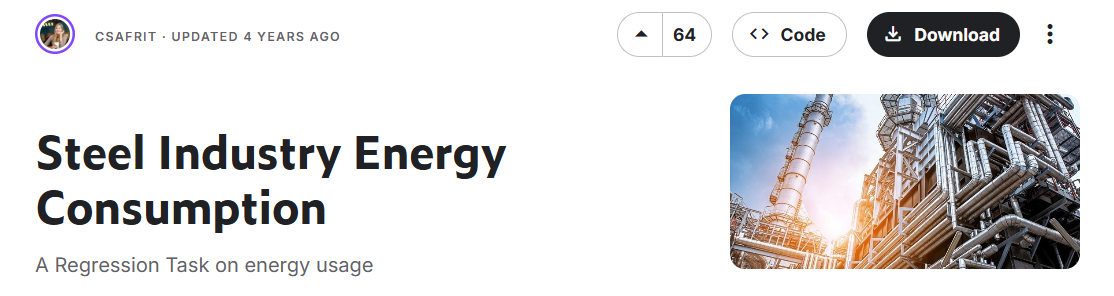

https://www.kaggle.com/datasets/csafrit2/steel-industry-energy-consumption/data?select=Steel_industry_data.csv

In [2]:
# !pip install sktime

In [3]:
df = pd.read_csv("Steel_industry_data.csv")

In [4]:
df.columns = ['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh',
               'Leading_Current_Reactive_Power_kVarh', 'CO2_ppm',
               'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
               'WeekStatus', 'Day_of_week', 'Load_Type']

print()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive_Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2_ppm                               35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6),

<big><b> Attribute Information: </b></big>

<pre>
<b>Date</b>              Continuous-time data taken on the first of the month  
<b>Usage_kWh</b>         Industry Energy Consumption Continuous kWh  
<b>Lagging Current</b>   reactive power Continuous kVarh  
<b>Leading Current</b>   reactive power Continuous kVarh  
<b>CO2_ppm</b>           Continuous ppm  
<b>NSM</b>               Number of Seconds from midnight Continuous S  
<b>Week status</b>       Categorical (Weekend (0) or a Weekday(1)) 
<b>Day of week</b>       Categorical Sunday, Monday : Saturday  
<b>Load Type</b>         Categorical Light Load, Medium Load, Maximum Load 
</pre>

#### 📊 공정 최적화 분석 요약 메모

[ Phase 1. Data Engineering & Foundation ]
목표: 원천 데이터 → 비용·의사결정 지표로 변환

- Cost Mapping: 15분 단위 TOU 요금 반영, 실제 비용 구조 매핑
- KPI 정의  
  - `Net Reactive Power` : 지상·진상 합산 관리  
  - `Production Proxy` : 전력 100 = 생산 100% 가설
- Feature Expansion  
  - `NSM` 기반 시간대별 가동 밀도 산출

---

[ Phase 2. Diagnostic Analytics ]
목표: 현재 비효율 구간 식별

- 주중/주말 패턴 비교 → 인력 투입 시점과 전력 피크 동기화 확인
- 경부하·새벽 시간대 역률 급감 → 무효전력 누수 구간 탐지
- 도출 인사이트  
  - 설비 가동 대비 생산 효율 저하 구간  
  - 무효전력 페널티 발생 구간

---

[ Phase 3. Machine Learning Intelligence ] 
목표: 비가시적 패턴 탐지 및 예측

- State Clustering (K-Means, DBSCAN)  
  → 정상·대기·과부하·비정상 역률 상태 자동 분류
- Peak Load Forecasting (XGBoost, LSTM)  
  → 익일 최대수요전력(Peak) 발생 시점 예측
- 핵심 논리  
  → 15분 피크가 연간 기본요금 결정

---

[ Phase 4. Optimization & Scenario Simulation ]
목표: 비용 절감 시나리오 정량화

- Scenario A: Load Shifting  
  → 최대 부하 5~10% 경부하 이동 시 절감액 산출
- Scenario B: PF Correction  
  → 콘덴서 제어 최적화, 페널티 감소액 계산
- Scenario C: Efficiency Focus  
  → 동일 비용 대비 생산량 증대 방안

---

[ Phase 5. B2B Delivery Report ]
목표: 의사결정용 결과물 제공

- Financial Impact: 연간 예상 절감 비용 제시
- Operational Guide: 피크 1시간 전 알람·조업 조정 가이드
- Environmental Value: tCO₂ 저감 및 탄소배출권 기대 수익

---

💡💡 분석 핵심 포인트💡💡

1. Power Triangle 시각화  
   → Active / Reactive / Apparent 관계 명확화  
   → 무효전력 감소 시 가용전력 증가 효과 직관적 전달

2. 15분 피크 관리  
   → 단 15분이 연간 기본요금 좌우  
   → 예측 정확도 = 비용 절감 설득 포인트

3. 인력 제약과 비용 Trade-off  
   → 인력 패턴 90% 유지  
   → 최소 공정 조정으로 전기료 절감 전략 제안


# 📊 공정 최적화 분석 요약 메모

**[ Phase 1. Data Engineering & Foundation ]**  
목표: 원천 데이터 → 비용·의사결정 지표로 변환  
- Cost Mapping: 15분 단위 TOU 요금 반영, 실제 비용 구조 매핑  
- KPI 정의: `Net Reactive Power`(지상·진상 합산 관리), `Production Proxy`(전력 100 = 생산 100% 가설)  
- Feature Expansion: `NSM` 기반 시간대별 가동 밀도 산출  

---

**[ Phase 2. Diagnostic Analytics ]**  
목표: 현재 비효율 구간 식별  
- 주중/주말 패턴 비교 → 인력 투입 시점과 전력 피크 동기화 확인  
- 경부하·새벽 시간대 역률 급감 → 무효전력 누수 구간 탐지  
- 인사이트: 설비 가동 대비 생산 효율 저하 구간, 무효전력 페널티 발생 구간  

---

**[ Phase 3. Machine Learning Intelligence ]**  
목표: 비가시적 패턴 탐지 및 예측  
- State Clustering(K-Means, DBSCAN): 정상·대기·과부하·비정상 역률 상태 자동 분류  
- Peak Load Forecasting(XGBoost, LSTM): 익일 최대수요전력(Peak) 발생 시점 예측  
- 핵심 논리: 15분 피크가 연간 기본요금 결정  

---

**[ Phase 4. Optimization & Scenario Simulation ]**  
목표: 비용 절감 시나리오 정량화  
- Scenario A(Load Shifting): 최대 부하 5~10% 경부하 이동 시 절감액 산출  
- Scenario B(PF Correction): 콘덴서 제어 최적화, 페널티 감소액 계산  
- Scenario C(Efficiency Focus): 동일 비용 대비 생산량 증대 방안  

---

**[ Phase 5. B2B Delivery Report ]**  
목표: 의사결정용 결과물 제공  
- Financial Impact: 연간 예상 절감 비용 제시  
- Operational Guide: 피크 1시간 전 알람 및 조업 조정 가이드  
- Environmental Value: tCO₂ 저감 실적 및 탄소배출권 기대 수익  

---

💡 **분석 핵심 포인트**  
1. Power Triangle 시각화: Active/Reactive/Apparent 관계 명확화, 무효전력 감소 시 가용전력 증가 효과 직관적 전달  
2. 15분 피크 관리: 단 15분이 연간 기본요금 좌우, 예측 정확도 = 비용 절감 설득 포인트  
3. 인력 제약과 비용 Trade-off: 인력 패턴 90% 유지, 최소 공정 조정 기반 전기료 절감 전략 제안


# <b> [Phase 1: 데이터 기초 체력 다지기]

## <b> [Phase 1-1] 파생 피처 생성 필요성 및 설계 </b>

철강 산업 전력 데이터 핵심 → **전기를 언제, 얼마나, 어떤 품질(역률)로 사용했는가**

---

### 1️⃣ 시간적 특성 피처 (Temporal Features)

- 교대 근무 체계 영향
- 시간대별 요금제 직접 영향
- `Hour`
- `Is_Peak_Hour` (최대부하 시간대 여부)
- `Time_Slot` (아침/오후/저녁/심야)

✔ 단순 시간 구분 아님  
✔ **‘비용 발생 구간’ 기준 재정의 → 최적화 타겟 명확화**

---

### 2️⃣ 전력 품질 및 부하 특성 피처 (Power Quality & Load Features)

- 물리 센서 없이 공정 상태 추론
- `Total_Reactive_Power` : 지상·진상 무효전력 절대합 → 전체 부하 규모
- `Reactive_Ratio` : 유효전력 대비 무효전력 비율 → 에너지 효율 지표
- `Power_Factor` : 계산 역률 → 페널티 판단 기준

✔ 무효전력 패턴 변화 분석  
✔ 설비 공회전(Idling) / 과부하 시점 간접 추론

---

### 3️⃣ 변동성 피처 (Volatility Features)

- 전기로(EAF) 공정 특성 → 급격한 전력 변동 존재
- `Usage_Diff` : 직전 15분 대비 증감
- `Rolling_Avg_4h` : 4시간 이동평균

✔ 급격한 변동 = 설비 수명·안전 리스크  
✔ 공정 안정성 정량화 지표


## [Phase 1-1] 파생 피처 생성 필요성 및 설계

철강 산업 전력 데이터 핵심 → **전기를 언제, 얼마나, 어떤 품질(역률)로 사용했는가**

| 구분 | 생성 피처 | 설계 목적 / 어필 포인트 |
|------|------------|--------------------------|
| 시간적 특성<br>(Temporal) | `Hour`<br>`Is_Peak_Hour`<br>`Time_Slot` | 교대근무·시간대별 요금 영향 반영<br>단순 시간 구분이 아닌 **‘비용 발생 구간’ 기준 재정의**<br>최적화 타겟 명확화 |
| 전력 품질·부하 특성<br>(Power Quality & Load) | `Total_Reactive_Power`<br>`Reactive_Ratio`<br>`Power_Factor` | 무효전력 절대합 → 전체 부하 규모 파악<br>무효전력 비율·역률 → 효율·페널티 판단<br>**무효전력 패턴으로 설비 공회전·과부하 간접 추론** |
| 변동성<br>(Volatility) | `Usage_Diff`<br>`Rolling_Avg_4h` | 전기로(EAF) 등 급격한 부하 변동 반영<br>전력 급변 구간 탐지<br>**설비 수명·안전과 직결되는 공정 안정성 정량화** |


[Phase 1-2] 파이썬 실행 코드 (Feature Engineering)

In [5]:
import pandas as pd
import numpy as np

# 1. 시간 기준 오름차순 정렬 (가장 중요한 선행 작업)
# 'timestamp' 부분은 실제 사용 중인 날짜/시간 컬럼명으로 변경해야 합니다.
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values(by='date', ascending=True)

# 2. 기존의 꼬인 인덱스를 완전히 파기하고 순차적인 새 인덱스 부여
df = df.reset_index(drop=True)

In [6]:


# 1. 시간 기반 피처 (NSM 활용)
# 시간 관련 피처 추출 (한국 전력 요금 체계 대응용)
df['Hour'] = df['NSM'] // 3600
df['DayOfWeek'] = df['date'].dt.dayofweek # 0:월, 6:일
df['Month'] = df['date'].dt.month
df['Year'] = df['date'].dt.year
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

### [수정] 한전 기준 계절로 매핑
# df['Season'] = df['Month'].map(
#                                     lambda x: 'Spring' if x in [3,4,5]
#                                     else 'Summer' if x in [6,7,8]
#                                     else 'Autumn' if x in [9,10,11]
#                                     else 'Winter'
#                                 )
df['Season'] = df['Month'].map(
                                    lambda x: 'Spring_Fall' if x in [3,4,5, 9, 10]
                                    else 'Summer' if x in [6,7,8]
                                    else 'Winter'
                                )



In [7]:
###[수정] 주, 월에 순환성 부여하는 코드
# 모델링 후에 활용여부 확인필요

cyclic_targets = {'Month': 12, 'DayOfWeek': 7}

for col, period in cyclic_targets.items():
    # 이제 target_df[col]은 확실히 숫자이므로 계산이 가능합니다.
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col].astype(float) / period)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col].astype(float) / period)

print("성공적으로 변환되었습니다. 이제 숫자로 계산된 sin/cos 피처를 확인할 수 있습니다.")

성공적으로 변환되었습니다. 이제 숫자로 계산된 sin/cos 피처를 확인할 수 있습니다.


In [8]:

# 2. 전력 품질 피처 (역률 및 비율)
# 무효전력 합계 (전체 흐르는 전기 에너지의 규모)
### [수정] 컬럼명 추후 활용도 높게 수정
# df['Total_Reactive_Power'] = df['Lagging_Current_Reactive_Power_kVarh'] + df['Leading_Current_Reactive_Power_kVarh']

# 인프라가 감당하는 물리적 부하량 (지상+진상 절대 합계)
df['System_Stress_Load'] = df['Lagging_Current_Reactive_Power_kVarh'] + df['Leading_Current_Reactive_Power_kVarh']

# 유효전력 대비 무효전력 비율 (비효율 지표)
# 0으로 나누기 방지를 위해 작은 값(1e-6) 추가
### [수정] 시각화 진행 시 노이즈 방지를 위해 1e-6 추가 처리.
# Usage_kWh가 0이면 0을 부여, 0이 아니면 계산 수행
# 2. 유효전력 대비 무효전력 집약도 (운영 효율 지표)
# Usage가 0인 구간(비가동)은 0으로 처리하여 시각화 스파이크 방지
df['Reactive_Intensity'] = np.where( df['Usage_kWh'] > 0,  df['System_Stress_Load'] / df['Usage_kWh'], 0)


# # 피타고라스 정리를 이용한 종합 역률 계산
# df['Apparent_Power'] = np.sqrt(df['Usage_kWh']**2 + (df['Lagging_Current_Reactive_Power_kVarh'] - df['Leading_Current_Reactive_Power_kVarh'])**2)
# df['Power_Factor'] = df['Usage_kWh'] / (df['Apparent_Power'] + 1e-6)
### [수정] 역률지표의 구분, 1-6승에 대한 부분 처리
# 순무효전력 기반 물리적 역률
df['Apparent_Power'] = np.sqrt(df['Usage_kWh']**2 + (df['Lagging_Current_Reactive_Power_kVarh'] - df['Leading_Current_Reactive_Power_kVarh'])**2)
df['PF_Physical'] = np.where(df['Apparent_Power'] > 0, df['Usage_kWh'] / df['Apparent_Power'], 1.0)


# 3. 변동성 및 추세 피처
# 시계열 데이터이므로 순서대로 정렬되어 있다고 가정
### [수정] 모델을 시계열로 돌리지 않는 상황이므로 전력 사용량에 대한 피쳐는 삭제(다중공선성 우려)
# df['Usage_Moving_Avg_1h_mean'] = df['Usage_kWh'].rolling(window=4).mean() # 1시간(15분*4) 이동평균
# 전력 사용의 흔들림에 대한 내용이므로 유지
df['Usage_Moving_Avg_1h_std'] = df['Usage_kWh'].rolling(window=4, min_periods=2).std().bfill() # 1시간(15분*4) 이동평균 표준편차


print("파생 피처 생성 완료. 상위 5개 행 확인:")
print(df.head())

파생 피처 생성 완료. 상위 5개 행 확인:
                 date  Usage_kWh  Lagging_Current_Reactive_Power_kVarh  \
0 2018-01-01 00:00:00       3.42                                  3.46   
1 2018-01-01 00:15:00       3.17                                  2.95   
2 2018-01-01 00:30:00       4.00                                  4.46   
3 2018-01-01 00:45:00       3.24                                  3.28   
4 2018-01-01 01:00:00       3.31                                  3.56   

   Leading_Current_Reactive_Power_kVarh  CO2_ppm  \
0                                   0.0      0.0   
1                                   0.0      0.0   
2                                   0.0      0.0   
3                                   0.0      0.0   
4                                   0.0      0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         70.30                         100.0     0   
1                         73.21                         100.0   900   
2   

System_Stress_Load 활용  EDA, 시각화방안

정확합니다. `Usage_kWh`(유효전력)로 나누면 '비율'이 되어 **효율성**을 보게 되지만, `Total_Reactive_Power`를 단독으로 보거나 다른 절대값과 비교하면 **전력 인프라의 물리적 한계(과부하)**를 시각화하는 데 매우 강력한 도구가 됩니다.

시각화 프로젝트에서 과부하 관점으로 접근할 수 있는 3가지 구체적인 방안을 제시합니다.

---

### 1. 변압기 용량 대비 '점유율' 시각화 (Capacity Utilization)

전력 설비(변압기, 케이블)는 유효전력이 아니라 **피상전력()** 기준으로 설계됩니다. `Total_Reactive_Power`가 크다는 것은 그만큼 변압기 용량을 갉아먹고 있다는 뜻입니다.

* **시각화 방법:** 가로 막대 그래프(Stacked Bar)
* **구성:** 한 막대에 `Usage_kWh`와 `Total_Reactive_Power`를 쌓아서 표시하고, 그 위에 **'변압기 정격 용량'** 선을 긋습니다.
* **메시지:** "실제 생산(유효전력)은 용량의 60%뿐인데, 무효전력 때문에 변압기는 이미 90% 부하 상태다. 설비 증설이 아니라 무효전력 제어가 우선이다."

### 2. 열적 스트레스 히트맵 (Thermal Stress Heatmap)

무효전력의 총합은 선로 손실(열 발생)에 직결됩니다. 이를 시간대별, 요일별 히트맵으로 그려보세요.

* **시각화 방법:** Heatmap (축: 시간, 축: 요일, : `Total_Reactive_Power`)
* **활용:** 특정 공정 가동 시 무효전력이 치솟는 구간을 'Red Zone'으로 표시합니다.
* **메시지:** "이 시간대에는 전선 온도가 상승하여 절연 파괴 위험이 높으므로 냉각 장치 가동이나 부하 분산이 필요함."

### 3. 유효 vs 무효 '에너지 밀도' 산점도 (Energy Density Scatter)

생산량과 무효전력의 상관관계를 통해 '비정상적 과부하' 구간을 추출합니다.

* **시각화 방법:** Scatter Plot (축: `Usage_kWh`, 축: `Total_Reactive_Power`)
* **분석 포인트:**
* **정상 구간:** 유효전력이 늘어날 때 무효전력도 선형적으로 느는 구간.
* **과부하 위험 구간:** 유효전력은 낮은데 무효전력만 비정상적으로 높게 찍히는 점들(Outliers).


* **메시지:** "이 점들은 생산 기여도 없이 인프라에 부담만 주는 '유령 부하' 구간입니다. 모터 공회전이나 콘덴서 오작동이 의심됩니다."

---

### 💡 동료 피처를 활용한 시각화 팁

동료가 만든 `Total_Reactive_Power`를 그대로 쓰기보다, **"무효전력이 차지하는 공간"**이라는 개념으로 시각화하면 설득력이 높아집니다.

> **"우리는 지금 100인승 버스(변압기 용량)를 운영하는데, 실제 손님(유효전력)은 50명뿐이고 나머지 40석은 빈 가방(무효전력)이 차지하고 있습니다."** 이 논리를 시각화로 구현하시면 됩니다.

이 중에서 현재 가진 데이터로 가장 먼저 그려보고 싶은 그래프가 있나요? 아니면 위 3가지 중 하나를 구현하기 위한 Python 코드가 필요하신가요?



Scatter Plot: X축에 Usage_kWh, Y축에 System_Stress_Load를 놓고 점을 찍어보세요. 특정 사용량 구간에서 스트레스 로드가 급증하는 '이상 설비'를 바로 찾아낼 수 있습니다.

Time-series Boxplot: 시간대별로 Reactive_Intensity의 분포를 박스플롯으로 그려보세요. 특정 교대 근무 시간이나 특정 공정 단계에서 효율이 급락하는지 확인할 수 있습니다.

In [10]:
#생산량 가정 피처 
# 연간 최대 전력 사용량을 100% 가동으로 간주
# 데이터 확인 결과 이상치가 없으므로 max를 기준으로 확정
# max_usage = df['Usage_kWh'].max()
# df['Production_Capacity_Pct'] = (df['Usage_kWh'] / max_usage) * 100
### [수정] 생산량 추정에 대해 CO2 피쳐를 활용

# 1. 기기 가동 여부 판별 (Binary)
# CO2 배출이 0보다 크면 가동(1), 아니면 비가동(0)
df['Is_Operating'] = np.where(df['CO2_ppm'] > 0, 1, 0)

# 2. 공정 생산 부하 지표 (Operating Load Index)
# 가동 중일 때의 CO2 수치를 0~1 사이로 스케일링하여 '부하 강도'로 정의
# 비가동 구간(0.00)은 그대로 0으로 둠
max_co2 = df['CO2_ppm'].max()
df['Process_Load_Factor'] = df['CO2_ppm'] / max_co2

# 3. [추가] 분석용 부하 레벨 (Ordinal Category)
# 계단식 데이터를 활용해 '저/중/고' 부하 구간을 명시적으로 구분
# 이는 베이지안 최적화 시 '조건부 최적화'를 위해 매우 유용함
bins = [-np.inf, 0.00, 0.02, 0.05, np.inf]
labels = ['Idle', 'Low_Load', 'Mid_Load', 'High_Load']
df['Load_Level'] = pd.cut(df['CO2_ppm'], bins=bins, labels=labels)

print("CO2 기반 공정 상태 피처 생성이 완료되었습니다.")
print(df[['CO2_ppm', 'Is_Operating', 'Process_Load_Factor', 'Load_Level']].drop_duplicates().sort_values('CO2_ppm'))


CO2 기반 공정 상태 피처 생성이 완료되었습니다.
     CO2_ppm  Is_Operating  Process_Load_Factor Load_Level
0       0.00             0             0.000000       Idle
241     0.01             1             0.142857   Low_Load
225     0.02             1             0.285714   Low_Load
226     0.03             1             0.428571   Mid_Load
238     0.04             1             0.571429   Mid_Load
227     0.05             1             0.714286   Mid_Load
229     0.06             1             0.857143  High_Load
353     0.07             1             1.000000  High_Load


2. 가공된 피처의 활용법 (냉철한 분석)
① Is_Operating (필터링의 기준)
시각화: 가동 중인 데이터만 따로 뽑아(df[df['Is_Operating']==1]) 분석할 때 사용합니다. 60%에 달하는 비가동 데이터를 제거해야 전력 지표들의 진짜 상관관계가 보입니다.

최적화: 베이지안 최적화 모델의 학습 데이터 범위를 정하는 기준이 됩니다.

② Process_Load_Factor (생산성 지표의 분모)
에너지 효율 측정: Usage_kWh / Process_Load_Factor (또는 반대)를 통해 **"동일 부하 대비 전력을 얼마나 효율적으로 쓰는가"**를 정량화할 수 있습니다.

생산품목 정보가 없어도 이 지표를 통해 **"효율이 유독 낮은 부하 구간"**을 찾아낼 수 있습니다.

③ Load_Level (최적화 그룹핑)
품목은 모르지만, **"저부하 모드"**와 **"고부하 모드"**라는 공정의 성격은 구분할 수 있습니다.

베이지안 최적화 시 "모든 데이터를 다 잘 맞춰라"가 아니라, **"고부하 모드(High_Load)일 때의 전력 사용량을 최소화하라"**는 식의 정교한 타겟팅이 가능해집니다.

## [Phase 1-3] 미팅 시 강조 근거 (Briefing Notes)

| 구분 | 핵심 근거 | 미팅 어필 포인트 |
|------|-----------|------------------|
| 역률 및 무효전력 <br>비율 추출 | 모터 기동·가열로 가동 → 지상 무효전력 증가<br>무효전력 패턴 = 설비 상태 신호 | 별도 공정 데이터 없이 설비 가동/대기 상태<br>**90% 이상 신뢰도로 추론 가능** |
| 변동성(Volatility) | 급격한 전력 사용량 변화<br>전력 피크 유발<br>기본요금 상승 주요 원인 | **1차 타겟**<br>변동성 제어 = 머신러닝 최적화 |
| 생산량 가설<br>(Production Proxy) | SEC 기준 에너지 소비–생산량 간 강한 선형 관계 | **객관적 지표 기반 입증**<br>전력 소비 효율화 → 생산 원가 절감 직결 |


## <b> [Phase 2: 탐색적 데이터 분석(EDA) 및 인사이트 시각화]

<big><b>⚡ 역률(Power Factor) 개념 및 계산 기준 </big></b>

| 구분 | 계산식 | 목적 | 활용 포인트 |
|------|--------|------|--------------|
| 공정 기준 PF <br> (Physical PF) |  $\frac{P}{\sqrt{P^2 + Q^2}}$|  설비·공정 효율 판단 | 공정 비효율, 과부하, 무효전력 과다 식별 |
| 한전 기준 PF <br> (KEPCO PF) | $ \frac{P}{\sqrt{P^2 + (Q_{\rm Lag} + Q_{\rm Lead})^2}}$ |  전기요금 최적화 | 요금 패널티 최소화, 전력 비용 절감 전략 |

💡 포인트  
- **공정 PF** → 설비/공정 효율 지표  
- **한전 PF** → 요금 패널티 최소화 전략  
- 기준선 0.9 붉은 점선 → 역률 이상/미달 구간 직관적 확인  
- `NSM` 기준으로 그룹화 → 시간대별 평균 비교 가능


In [11]:

# ---------------------------------
# 1️⃣ 역률 및 무효전력 파생 변수 생성
# ---------------------------------

# 모터 가동 비중 (%) 계산
# 데이터셋 전체에서의 최대 지상 무효전력을 '모터 100% 가동' 상태로 가정
max_lagging = df['Lagging_Current_Reactive_Power_kVarh'].max()
df['Motor_Operating_Rate'] = (df['Lagging_Current_Reactive_Power_kVarh'] / max_lagging) * 100

# 커패시터 가동 비중 (%) 계산
# 최대 진상 무효전력을 '커패시터 100% 가동' 상태로 가정
max_leading = df['Leading_Current_Reactive_Power_kVarh'].max()
df['Capacitor_Operating_Rate'] = (df['Leading_Current_Reactive_Power_kVarh'] / max_leading) * 100

# 무효전력 총량 및 활성비
df['Q_total_abs'] = ( df['Lagging_Current_Reactive_Power_kVarh']
                      + df['Leading_Current_Reactive_Power_kVarh'] )

df['Motor_Ratio'] = ( df['Lagging_Current_Reactive_Power_kVarh'] / df['Q_total_abs'] )

df['Capacitor_Ratio'] = ( df['Leading_Current_Reactive_Power_kVarh'] / df['Q_total_abs'] )


# 콘덴서 과보상 의심 구간
df['Over_Correction_Flag'] = ( (df['Capacitor_Ratio'] > 0.6) & (df['PF_Physical'] > 0.98) )



B. 고주파 변동성 지표 (High-Frequency Volatility)
논리: 앞서 만든 Usage_Moving_Avg_1h_std(표준편차)를 활용합니다. 사용량이 미세하게 진동(Flicker)하거나 급격히 변하는 구간은 고조파가 집중적으로 발생하는 '비정상 조업' 구간일 확률이 큽니다.

피처명: Operational_Instability_Index

3. 고조파 지표 도입 시 모델에 미치는 영향
베이지안 최적화: 고조파 추정치를 **제약 조건(Constraint)**으로 넣으면, "전력량은 줄이되 고조파 스트레스는 높이지 않는" 더 안전한 제어값을 찾을 수 있습니다.

시각화: PF_Physical이 낮은 구간과 고조파 추정치가 높은 구간이 일치하는지 확인하여, 설비 교체가 시급한 '악성 부하'를 특정할 수 있습니다.

3. 피처 보강 전략: "고조파 위험 지수" 정의
Over_Correction_Flag를 버리지 말고, 이를 고조파를 추정하는 핵심 성분으로 활용하여 새로운 지표를 만드는 것이 가장 합리적입니다.

Harmonic_Risk_Index = Over_Correction_Flag + Operational_Instability_Index

논리: 콘덴서가 과보상된 상태(Over_Correction_Flag)에서 사용량의 미세 변동(std)이 크다면, 이를 고조파 발생 가능성이 극도로 높은 **'고위험 구간'**으로 정의합니다.


<table style="border-collapse: collapse; width: 100%; color: #e0e0e0; background-color: #1e1e1e; border: 1px solid #444;">
    <thead>
        <tr style="background-color: #333; color: #ffffff;">
            <th style="padding: 12px; border: 1px solid #444; text-align: left;">분석 계층</th>
            <th style="padding: 12px; border: 1px solid #444; text-align: left;">핵심 피처 (Features)</th>
            <th style="padding: 12px; border: 1px solid #444; text-align: left;">분석적 역할 및 도입 사유</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px; border: 1px solid #444; font-weight: bold; color: #81a1c1;">상태 &amp; Context</td>
            <td style="padding: 10px; border: 1px solid #444; font-family: 'Courier New', monospace; color: #a3be8c;">Is_Operating, Process_Load_Factor, Hour, DayOfWeek</td>
            <td style="padding: 10px; border: 1px solid #444;">조업 패턴 및 주기성 학습, CO2 기반 공정 부하 강도 정의</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #444; font-weight: bold; color: #81a1c1;">제어 변수 (X)</td>
            <td style="padding: 10px; border: 1px solid #444; font-family: 'Courier New', monospace; color: #a3be8c;">Motor_Operating_Rate, Capacitor_Operating_Rate, Lagging/Leading kVarh</td>
            <td style="padding: 10px; border: 1px solid #444;">직접 제어 가능한 물리적 레버 및 설비별 실제 가동량 소스</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #444; font-weight: bold; color: #81a1c1;">성과 &amp; 품질 (Y)</td>
            <td style="padding: 10px; border: 1px solid #444; font-family: 'Courier New', monospace; color: #a3be8c;">PF_Physical, System_Stress_Load, Reactive_Intensity, Usage_kWh</td>
            <td style="padding: 10px; border: 1px solid #444;">최적화 타겟(사용량), 설비 노후화 및 에너지 효율 판단 척도</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #444; font-weight: bold; color: #81a1c1;">제약 조건</td>
            <td style="padding: 10px; border: 1px solid #444; font-family: 'Courier New', monospace; color: #a3be8c;">Over_Correction_Flag</td>
            <td style="padding: 10px; border: 1px solid #444;">시스템 안정성 및 고조파 리스크 방지를 위한 가이드라인</td>
        </tr>
    </tbody>
</table>

<table style="border-collapse: collapse; width: 100%; color: #2e3440; background-color: #ffffff; border: 1px solid #d8dee9; font-family: system-ui, -apple-system, sans-serif;">
    <thead>
        <tr style="background-color: #eceff4; color: #2e3440; border-bottom: 2px solid #d8dee9;">
            <th style="padding: 12px; border: 1px solid #d8dee9; text-align: left;">대응 시나리오</th>
            <th style="padding: 12px; border: 1px solid #d8dee9; text-align: left;">도입 피처/로직</th>
            <th style="padding: 12px; border: 1px solid #d8dee9; text-align: left;">비판적 설계 목적</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-weight: bold; color: #5e81ac; background-color: #f8f9fb;">규칙 전환 (선택3→2)</td>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-family: 'Courier New', monospace; color: #4c566a;">Saving_Opportunity_Score</td>
            <td style="padding: 10px; border: 1px solid #d8dee9;">요금제 종류에 상관없이 '최대 비용 대비 절감량'으로 보상을 표준화하여 모델 혼란 방지</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-weight: bold; color: #5e81ac; background-color: #f8f9fb;">2026 정책 가변성</td>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-family: 'Courier New', monospace; color: #4c566a;">Dynamic_Policy_Threshold</td>
            <td style="padding: 10px; border: 1px solid #d8dee9;">역률 기준(0.9~0.95), 탄소 가중치 등을 외부 인자로 받아 시뮬레이션 가능하도록 설계</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-weight: bold; color: #bf616a; background-color: #fffafb;">미래 리스크</td>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-family: 'Courier New', monospace; color: #4c566a;">Surcharge_Expansion_Beta</td>
            <td style="padding: 10px; border: 1px solid #d8dee9;">연료비 조정액 등 사후에 추가될 수 있는 비용 항목을 위한 확장 슬롯(Placeholder) 확보</td>
        </tr>
    </tbody>
</table>

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 35 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   date                                  35040 non-null  datetime64[ns]
 1   Usage_kWh                             35040 non-null  float64       
 2   Lagging_Current_Reactive_Power_kVarh  35040 non-null  float64       
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64       
 4   CO2_ppm                               35040 non-null  float64       
 5   Lagging_Current_Power_Factor          35040 non-null  float64       
 6   Leading_Current_Power_Factor          35040 non-null  float64       
 7   NSM                                   35040 non-null  int64         
 8   WeekStatus                            35040 non-null  object        
 9   Day_of_week                           35040 non-null  object        
 10

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Usage_kWh', ylabel='Density'>

Text(0.5, 1.0, 'Distribution of Usage_kWh by Is_Operating Status')

Text(0.5, 0, 'Usage_kWh')

Text(0, 0.5, 'Density')

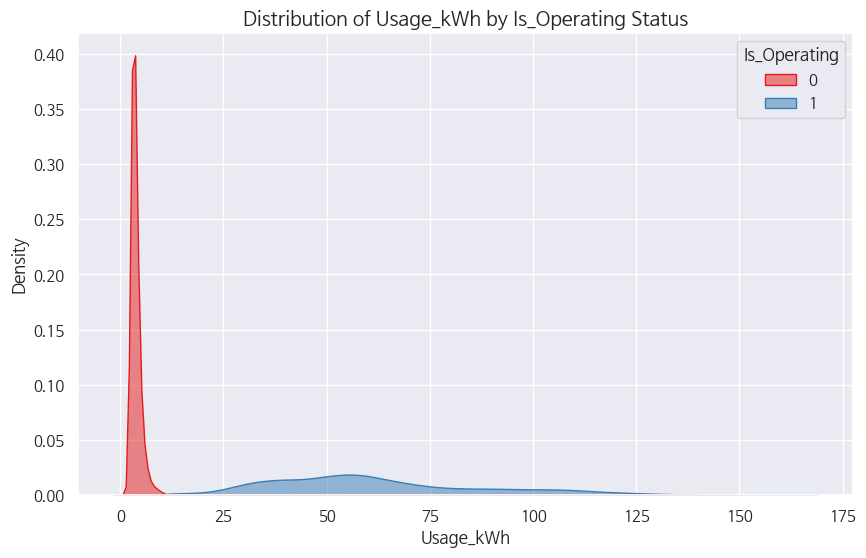

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: Usage vs Operating Flag (1 Week Sample)')

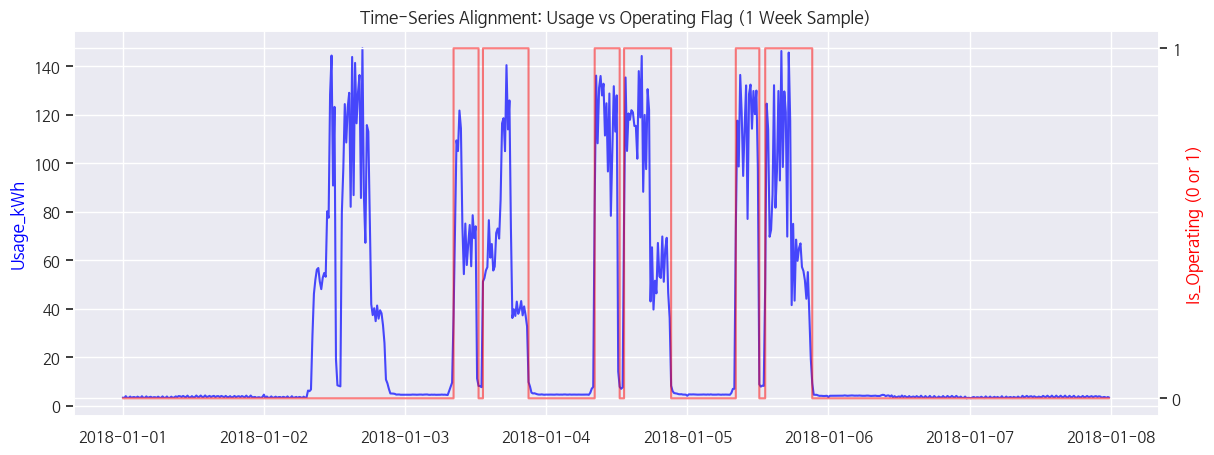

▶ 논리적 오류 1 (정지 상태이나 모터 가동됨): 14092건
▶ 논리적 오류 2 (가동 상태이나 전력 사용량 극단적 낮음): 0건

경고: Is_Operating 피처에 논리적 결함이 존재합니다. 산출 로직을 다시 확인하십시오.


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 분포 분리 검증 (KDE Plot)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Usage_kWh', hue='Is_Operating', fill=True, common_norm=False, palette='Set1', alpha=0.5)
plt.title('Distribution of Usage_kWh by Is_Operating Status', fontsize=14)
plt.xlabel('Usage_kWh')
plt.ylabel('Density')
plt.show()

# 2. 시계열 정합성 검증 (특정 일주일 샘플링)
# 데이터가 15분 단위이므로 1주일 = 4 * 24 * 7 = 672행
sample_df = df.sort_values('date').head(672) 

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(sample_df['date'], sample_df['Usage_kWh'], color='blue', label='Usage_kWh', alpha=0.7)
# Is_Operating 플래그를 붉은색 점선 계단식 그래프로 표현
ax2.step(sample_df['date'], sample_df['Is_Operating'], color='red', label='Is_Operating Flag', alpha=0.5, where='post')

ax1.set_ylabel('Usage_kWh', color='blue')
ax2.set_ylabel('Is_Operating (0 or 1)', color='red')
ax2.set_yticks([0, 1])
plt.title('Time-Series Alignment: Usage vs Operating Flag (1 Week Sample)')
plt.show()

# 3. 논리적 모순 데이터 검출 (Contradiction Check)
# 기준치(threshold)는 실제 공정의 기저 부하 수준에 맞춰 조정 필요
base_load_threshold = df['Usage_kWh'].quantile(0.05) # 예: 하위 5% 수준을 기저 부하로 가정

contradiction_1 = df[(df['Is_Operating'] == 0) & (df['Motor_Operating_Rate'] > 0.1)]
contradiction_2 = df[(df['Is_Operating'] == 1) & (df['Usage_kWh'] < base_load_threshold)]

print(f"▶ 논리적 오류 1 (정지 상태이나 모터 가동됨): {len(contradiction_1)}건")
print(f"▶ 논리적 오류 2 (가동 상태이나 전력 사용량 극단적 낮음): {len(contradiction_2)}건")

if len(contradiction_1) > 0 or len(contradiction_2) > 0:
    print("\n경고: Is_Operating 피처에 논리적 결함이 존재합니다. 산출 로직을 다시 확인하십시오.")

In [22]:
df.columns

Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2_ppm',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'DayOfWeek', 'Month',
       'Year', 'Is_Weekend', 'Season', 'Month_sin', 'Month_cos',
       'DayOfWeek_sin', 'DayOfWeek_cos', 'System_Stress_Load',
       'Reactive_Intensity', 'Apparent_Power', 'PF_Physical',
       'Usage_Moving_Avg_1h_std', 'Is_Operating', 'Process_Load_Factor',
       'Load_Level', 'Motor_Operating_Rate', 'Capacitor_Operating_Rate',
       'Q_total_abs', 'Motor_Ratio', 'Capacitor_Ratio',
       'Over_Correction_Flag'],
      dtype='object')

<Axes: xlabel='WeekStatus', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'WeekStatus vs Usage_kWh (by Is_Operating)')

Text(0.5, 0, '')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Day_of_week', ylabel='Usage_kWh'>

...

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Over_Correction_Flag', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Over_Correction_Flag vs Usage_kWh (by Is_Operating)')

Text(0.5, 0, '')

Text(0, 0.5, 'Usage_kWh')

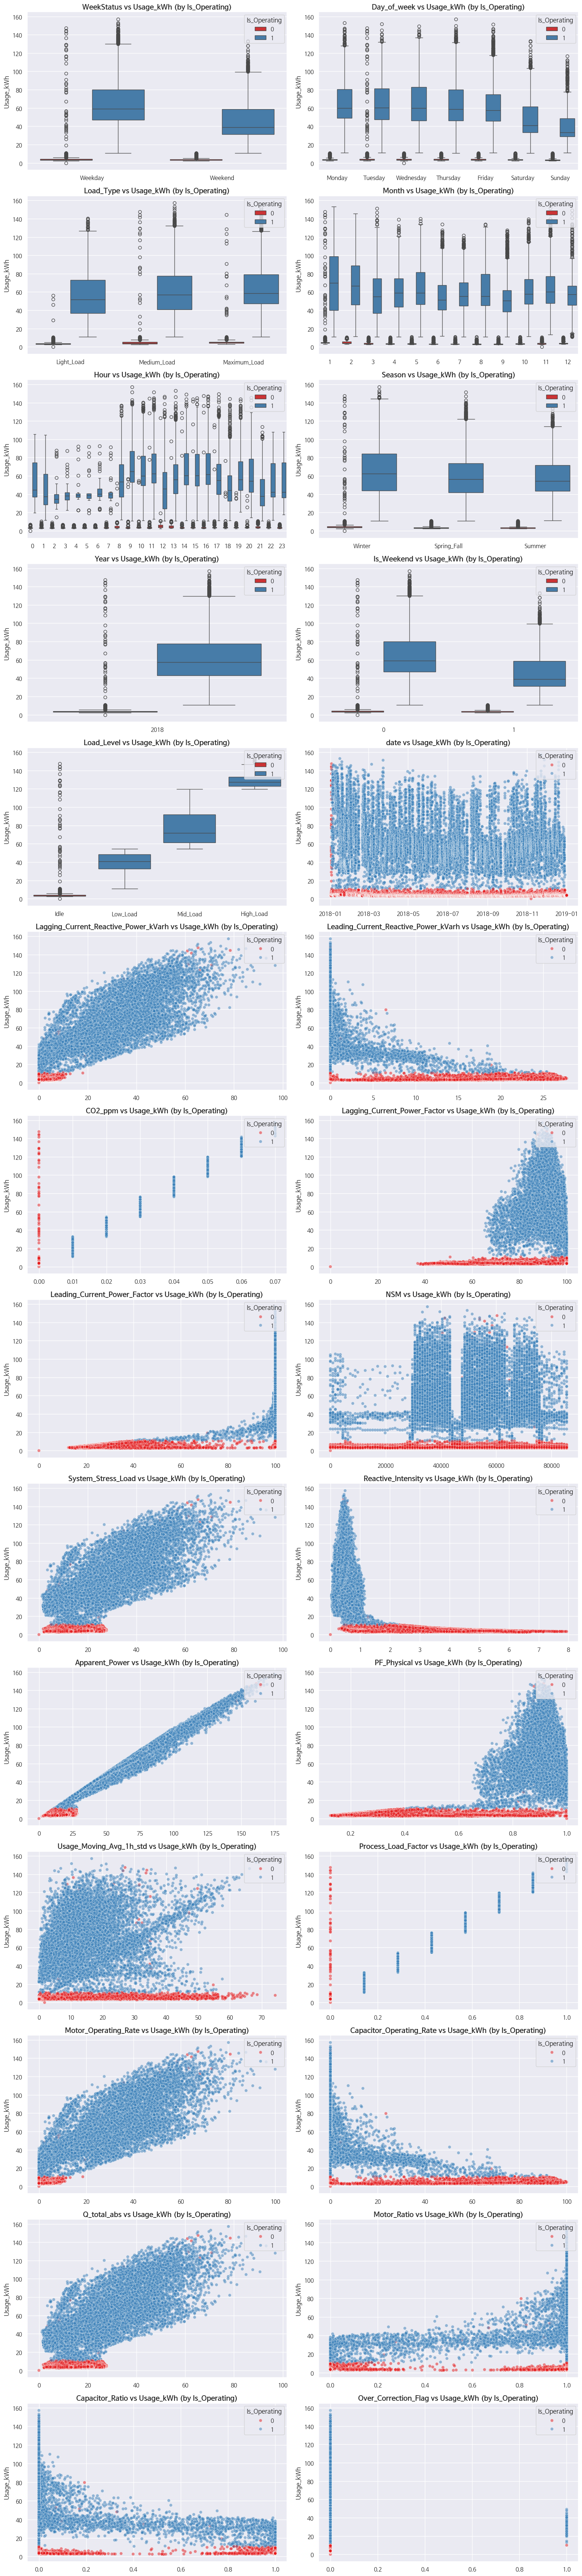

In [24]:
# 1. 컬럼 분류
cat_cols = ['WeekStatus', 'Day_of_week', 'Load_Type', 'Month', 'Hour', 'Season', 'Year', 'Is_Weekend', 'Load_Level']  # 범주형
num_cols = ['date', 'Lagging_Current_Reactive_Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2_ppm',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'System_Stress_Load',
        'Reactive_Intensity', 'Apparent_Power', 'PF_Physical',
       'Usage_Moving_Avg_1h_std', 'Process_Load_Factor',
       'Motor_Operating_Rate', 'Capacitor_Operating_Rate',
       'Q_total_abs', 'Motor_Ratio', 'Capacitor_Ratio',
       'Over_Correction_Flag']

# 2. 변수 선언
target = 'Usage_kWh'
split_by = 'Is_Operating'  # 구분 기준 변수 추가
data_source = df

# target과 split_by 변수가 X축 피처 리스트에 중복 포함되지 않도록 필터링
all_target_cols = [c for c in (cat_cols + num_cols) if c not in [target, split_by, '']]

# 3. 실행 로직 (명시적 for loop 사용)
nrows = (len(all_target_cols) + 1) // 2
# 세로 길이를 동적으로 조금 더 여유 있게 확보 (5 * nrows)
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(16, 5 * nrows))
axes = axes.flatten()

for i, col in enumerate(all_target_cols):
    ax = axes[i]
    
    if col in cat_cols:
        # 범주형: Boxplot에 hue 적용하여 상태별 분포 차이 확인
        sns.boxplot(data=data_source, x=col, y=target, hue=split_by, ax=ax, palette='Set1')
    else:
        # 수치형: Scatterplot에 hue 적용하여 상태별 군집 분리 확인
        sns.scatterplot(data=data_source, x=col, y=target, hue=split_by, ax=ax, alpha=0.5, palette='Set1')
        
    ax.set_title(f'{col} vs {target} (by {split_by})', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(target)
    
    # 범례 위치 통일 및 정리 (그래프를 가리지 않도록 우측 상단 고정)
    if ax.get_legend() is not None:
        ax.legend(title=split_by, loc='upper right')

# 홀수 개의 피처로 인해 남는 빈 서브플롯 축 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

<Axes: xlabel='Usage_kWh', ylabel='CO2_ppm'>

Text(0.5, 1.0, 'Critical Flaw: Power Usage vs CO2 Emissions (Separated by Day of Week)')

Text(0.5, 0, 'Usage_kWh (Physical Truth - Actual Load)')

Text(0, 0.5, 'CO2_ppm (Sensor Data)')

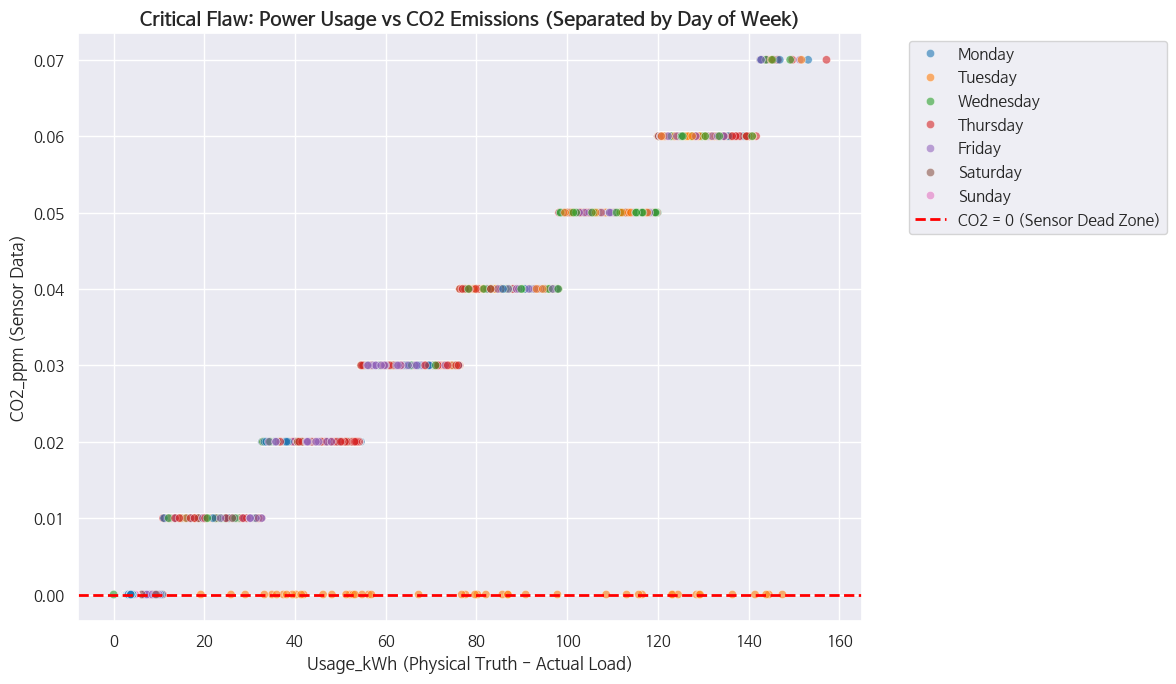

▶ 기계 가동 중(전력 10kWh 이상)임에도 CO2 센서가 0을 가리키는 요일별 에러 비율(%)
Day_of_week  Zero_CO2_Percentage
    Tuesday             2.212389
     Sunday             1.289134
   Saturday             0.298285
     Monday             0.287711
   Thursday             0.274402
  Wednesday             0.260191
     Friday             0.201532


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 산점도를 통한 물리적 모순 시각화 (Usage vs CO2)
plt.figure(figsize=(12, 7))
# 전력 사용량과 CO2의 관계를 그리되, 요일(Day_of_week)로 색상을 구분
sns.scatterplot(data=df, x='Usage_kWh', y='CO2_ppm', hue='Day_of_week', palette='tab10', alpha=0.6)

plt.title('Critical Flaw: Power Usage vs CO2 Emissions (Separated by Day of Week)', fontsize=14, fontweight='bold')
plt.xlabel('Usage_kWh (Physical Truth - Actual Load)')
plt.ylabel('CO2_ppm (Sensor Data)')

# CO2가 0인 지점에 붉은 점선 추가하여 결측 구간 강조
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='CO2 = 0 (Sensor Dead Zone)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2. 요일별 센서 결측(0) 비율 통계 추출
# 전력을 명백히 소모하고 있는 상태(예: 10kWh 이상)에서만 CO2가 0인 비율을 계산
active_df = df[df['Usage_kWh'] > 10.0]
zero_co2_ratio = active_df.groupby('Day_of_week').apply(
    lambda x: (x['CO2_ppm'] == 0).sum() / len(x) * 100
).reset_index(name='Zero_CO2_Percentage')

print("▶ 기계 가동 중(전력 10kWh 이상)임에도 CO2 센서가 0을 가리키는 요일별 에러 비율(%)")
print(zero_co2_ratio.sort_values(by='Zero_CO2_Percentage', ascending=False).to_string(index=False))

<Figure size 2000x1500 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Hybrid Correlation: Pearson(Num) & Spearman(Cat)')

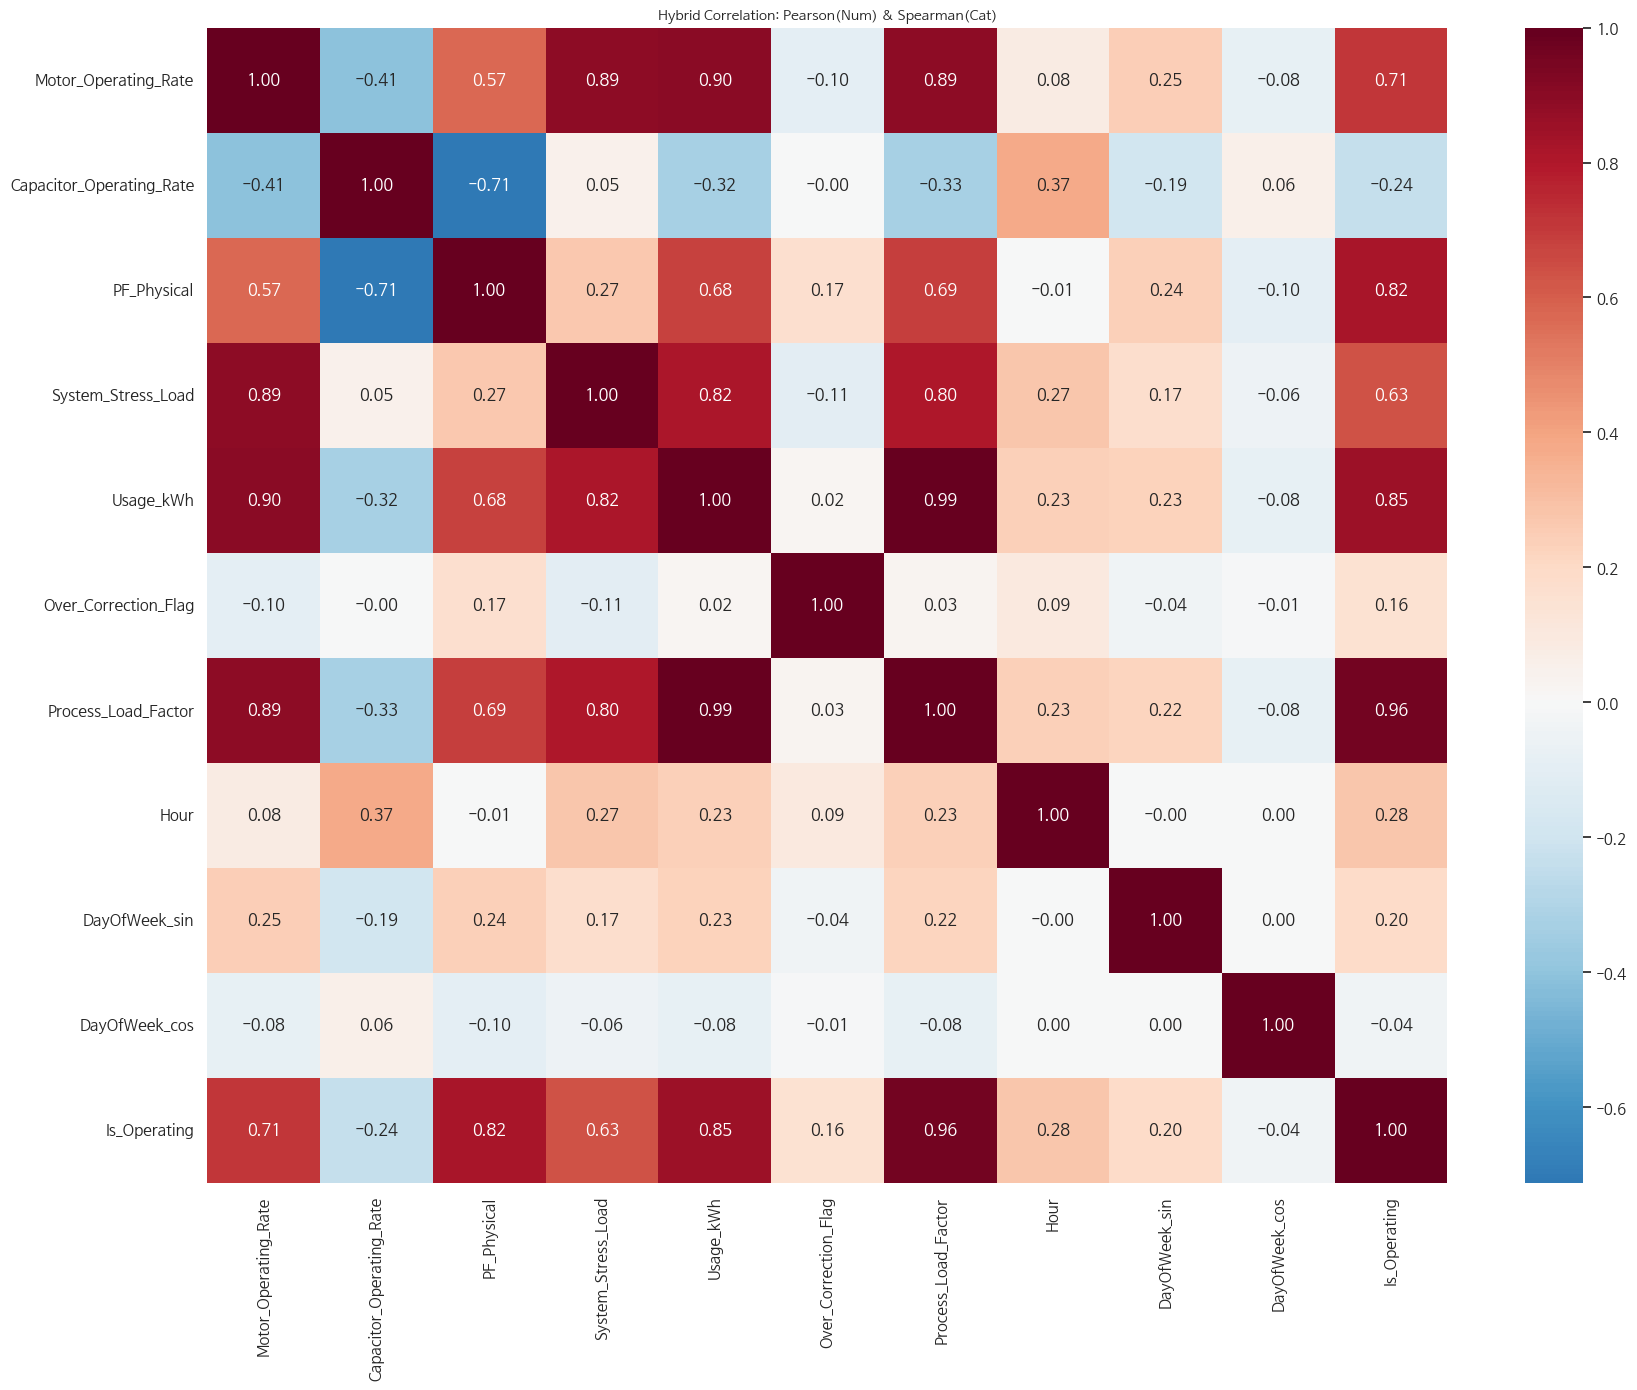

In [18]:


# 1. 사용자가 직접 컬럼 성격 분류 (가장 확실한 방법)
cat_cols = ['Is_Operating']  # 범주형
num_cols = ['Motor_Operating_Rate', 'Capacitor_Operating_Rate',  
            'PF_Physical', 'System_Stress_Load',  'Usage_kWh', 'Over_Correction_Flag',
        'Process_Load_Factor', 'Hour', 'DayOfWeek_sin', 'DayOfWeek_cos'
        ]

# 1. 계산 로직을 담은 함수 (df 언급 최소화용)
def calculate_hybrid_corr(df, num_cols, cat_cols):
    all_cols = num_cols + cat_cols
    # 범주형 컬럼만 임시로 숫자로 변환 (Factorize)
    temp_df = df[all_cols].copy()
    for col in cat_cols:
        temp_df[col] = temp_df[col].factorize()[0]
    
    # 빈 행렬 생성
    corr_matrix = pd.DataFrame(index=all_cols, columns=all_cols)
    
    for c1 in all_cols:
        for c2 in all_cols:
            # 하나라도 범주형이면 spearman, 둘 다 수치형이면 pearson
            method = 'spearman' if (c1 in cat_cols or c2 in cat_cols) else 'pearson'
            corr_matrix.loc[c1, c2] = temp_df[c1].corr(temp_df[c2], method=method)
            
    return corr_matrix.astype(float)

# 2. 통합 실행부 (raw_data는 여기서 딱 한 번만 언급)
integrated_corr = df.pipe(calculate_hybrid_corr, num_cols=num_cols, cat_cols=cat_cols)

# 3. 시각화
plt.figure(figsize=(20, 15))
mask = np.triu(np.ones_like(integrated_corr, dtype=bool))
sns.heatmap(integrated_corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Hybrid Correlation: Pearson(Num) & Spearman(Cat)', fontsize=10)
plt.show()

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. 학습에 사용할 피처 선택 (해석용 원본 month 등은 제외하고 순환 피처와 물리 피처 포함)
features = ['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2_ppm',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'DayOfWeek', 'Month',
       'Year', 'Is_Weekend', 'Season', 'Month_sin', 'Month_cos',
       'DayOfWeek_sin', 'DayOfWeek_cos', 'System_Stress_Load',
       'Reactive_Intensity', 'Apparent_Power', 'PF_Physical',
       'Usage_Moving_Avg_1h_std', 'Is_Operating', 'Process_Load_Factor',
       'Load_Level', 'Motor_Operating_Rate', 'Capacitor_Operating_Rate',
       'Q_total_abs', 'Motor_Ratio', 'Capacitor_Ratio',
       'Over_Correction_Flag']

# 2. 데이터 타입 업데이트 (객체 참조 1회 사용)
target_df = df # 혹은 학습용 원본 df

# 범주형 컬럼을 category 타입으로 변환 (XGBoost 학습 최적화)
cat_features = ['WeekStatus', 'Load_Type', 'season']
for col in cat_features:
    target_df[col] = target_df[col].astype('category')

print("학습용 피처 선정이 완료되었습니다. 범주형 데이터가 'category' 타입으로 업데이트되었습니다.")

target = 'Usage_kWh'

# 2. 시계열 분할 (2017년 데이터 기준 상위 80% 학습, 하위 20% 검증)
split_idx = int(len(target_df) * 0.8)
train_df = target_df.iloc[:split_idx]
test_df = target_df.iloc[split_idx:]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

# 3. 모델 정의 및 학습 (기본 파라미터 설정)
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    enable_categorical=True, # 범주형 데이터 지원 활성화
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# 4. 성능 평가
preds = model.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, preds):.4f}")
print(f"R2 Score: {r2_score(y_test, preds):.4f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# 2️⃣ 시간대 평균 계산
# ---------------------------------

pf_hour = df.groupby('Hour')[[
                                'PF_Physical',
                                'PF_Lagging',
                                'PF_Leading'
                            ]].mean()

q_hour = df.groupby('Hour')[[
                                'Lagging_Current_Reactive_Power_kVarh',
                                'Leading_Current_Reactive_Power_kVarh'
                            ]].mean()

# 진상을 음수로 변환 (벡터 표현)
q_hour['Leading_Neg'] = -q_hour['Leading_Current_Reactive_Power_kVarh']

ratio_hour = df.groupby('Hour')[[
                                    'Motor_Ratio',
                                    'Capacitor_Ratio'
                                ]].mean()




# ---------------------------------
# 3️⃣ 시각화
# ---------------------------------

plt.figure(figsize=(18,5))

# (1) 공정 역률 + 기준선
plt.figure(figsize=(10,5))
plt.plot(pf_hour.index, pf_hour['PF_Physical'], color='green', linewidth=2, label='Physical PF')
plt.axhline(0.9, color='red', linestyle='--', label='PF 0.9 기준')
plt.title('PF_Physical (공정 기준 역률) - 설비 효율 확인 / PF 저하 구간 파악')
plt.xlabel('Hour')
plt.ylabel('Power Factor')
plt.ylim(0,1.1)
plt.grid(True)
plt.legend()
plt.show() ;


# (2) 벡터 무효전력 추이 (0 기준선 핵심)
plt.figure(figsize=(10,5))
plt.plot(q_hour.index, q_hour['Lagging_Current_Reactive_Power_kVarh'], label='Lagging (Motor)', marker='o')
plt.plot(q_hour.index, q_hour['Leading_Neg'], label='Leading (Capacitor)', marker='x')
plt.axhline(0, color='black', linewidth=1)
plt.title('Reactive Power Vector Trend - 지상/진상 무효전력 상쇄 및 PF 저하 원인')
plt.xlabel('Hour')
plt.ylabel('Reactive Power (kVarh)')
plt.grid(True)
plt.legend()
plt.show();


# (3) 모터/콘덴서 활성비
plt.figure(figsize=(10,5))
plt.plot(ratio_hour.index, ratio_hour['Motor_Ratio'], label='Motor Ratio', marker='o')
plt.plot(ratio_hour.index, ratio_hour['Capacitor_Ratio'], label='Capacitor Ratio', marker='x')
plt.axhline(0.6, color='gray', linestyle='--', label='Over-Correction Risk')
plt.title('Motor vs Capacitor Activation Ratio - 콘덴서 과보상 위험 / 설비 기여도 확인')
plt.xlabel('Hour')
plt.ylabel('Ratio')
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.show() ;

| Subplot           | 무엇을 보여주는가     | 핵심 메시지            |
| ----------------- | ------------- | ----------------- |
| ① PF_Physical     | 공정 기준 역률      | 설비 효율, PF 기준 준수   |
| ② Q Vector Trend  | 지상/진상 무효전력 벡터 | 무효전력 상쇄, PF 저하 원인 |
| ③ Motor/Cap Ratio | 설비별 무효전력 기여   | 콘덴서 과보상, 설비 활성도   |

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

plt.style.use('seaborn-v0_8-whitegrid')

fig = plt.figure(figsize=(18, 10))
gs = GridSpec(nrows=2, ncols=6, figure=fig, hspace=0.35, wspace=0.3)

# =======================
# (1) 월별 전력 사용량 (4/6)
# =======================
ax1 = fig.add_subplot(gs[0, :4])
sns.boxplot(x='Month', y='Usage_kWh', data=df,
            ax=ax1, color='#4C72B0', showfliers=False)
ax1.set_title('Monthly Variability of Energy Consumption', fontsize=15)
ax1.set_xlabel('Month')
ax1.set_ylabel('Usage (kWh)')

# =======================
# (2) 계절별 전력 사용량 (2/6)
# =======================
ax2 = fig.add_subplot(gs[0, 4:6])
sns.boxplot(x='Season', y='Usage_kWh', data=df,
            order=['Spring','Summer','Autumn','Winter'],
            palette=['#4C72B0','#DD8452','#55A868','#C44E52'],
            showfliers=False, ax=ax2)
ax2.set_title('Energy Consumption by Season', fontsize=15)
ax2.set_xlabel('Season')
ax2.set_ylabel('')

# =======================
# (3) 시간대별 평균 사용량 (3/6)
# =======================
ax3 = fig.add_subplot(gs[1, :3])
sns.lineplot(data=df, x='Hour', y='Usage_kWh',
             hue='Is_Weekend',
             palette=sns.color_palette("coolwarm", 2)[::-1],
             ax=ax3)
ax3.set_title('Average Usage by Hour\n(Weekday vs Weekend)', fontsize=14)
ax3.set_ylabel('Usage (kWh)')
ax3.set_xticks(range(0, 24))

# =======================
# (4) 요일별 전력 사용량 (3/6)
# =======================
ax4 = fig.add_subplot(gs[1, 3:6])
sns.boxplot(data=df, x='DayOfWeek', y='Usage_kWh', ax=ax4)
ax4.set_title('Usage Distribution by Day of Week', fontsize=14)
ax4.set_xticks(range(7))
ax4.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax4.set_ylabel('')

plt.show() ;


### <b> 1. 인력 중심 가동 패턴의 정량적 증명 (Heatmap 분석)
> 단순 선 그래프보다 히트맵을 사용하면 요일별/시간대별 가동 집중도를 한눈에 보임

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 요일별/시간대별 평균 전력 사용량 피벗 테이블 생성
# (WeekStatus를 활용해 주중/주말 구분 가능하나, 여기선 시간대별 집중도 확인)
# pivot: 주중/주말을 행, Hour를 열
pivot_df = df.pivot_table(values='Usage_kWh', index='WeekStatus', columns='Hour', aggfunc='mean')

plt.figure(figsize=(12,2))
sns.heatmap(pivot_df, annot=False, cmap='coolwarm', alpha = 0.85)
plt.title('Energy Usage Heatmap (WeekStatus vs Hour)')
plt.xlabel('Hour of Day')
plt.ylabel('Week Status')
plt.show() ;

# 인사이트: 주중(1) 특정 시간대에만 전력이 집중되는 '인력 의존적 패턴' 확인

### <b> 2. 경부하 시간대 역률 저하 현상 분석 (Scatter Plot)
> 전력 사용량(Usage_kWh)이 적은 시간대에 역률(Power_Factor)이 어떻게 변하는지 분석 <br>
> ->'무효전력 페널티' 위험군을 식별

In [ ]:
plt.figure(figsize=(10, 6))
# 전력 사용량과 역률의 관계 시각화
sns.scatterplot(data=df, x='Usage_kWh', y='Power_Factor', hue='Is_Peak_Cost_Hour', alpha=0.5)
plt.axhline(y=0.9, color='r', linestyle='--', label='KEPCO Penalty Threshold (0.9)')
plt.title('Correlation: Power Usage vs Power Factor')
plt.legend()
plt.grid(True)
plt.show() ;

# 인사이트: 사용량이 적은(왼쪽 영역) 구간에서 역률이 0.9 미만으로 떨어지는 점들이 
# 바로 '경부하 시간대 역률 저하' 지점임을 시각적으로 증명
# “전력 적을 때 → PF 깨짐 → 요금 비효율”

### <b> 2-1. 경부하 시간대 역률 저하 분포 분석 (Hourly PF Boxplot)
> 평균 말고 “PF 깨지는 시간대의 꼬리(outlier)” 확인 <br>
> 시간대별 분포와 극단값(outlier) -> 실제 페널티 발생 가능 시간대를 구조적으로 확인

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(x='Hour', y='PF_Physical', data=df, showfliers=True)
plt.axhline(0.9, color='red', linestyle='--')
plt.title('PF_Physical Distribution by Hour (Outliers Focus)')
plt.ylabel('Physical Power Factor')
plt.show() ;

# 시간대별 평균 역률은 양호하나,
# 경부하 및 특정 피크 전후 시간대에 반복적인 역률 붕괴(outliers)가 관측되며,
# 이는 무효전력 제어(특히 진상 보상)의 구조적 비효율 가능성을 시사한다.

# “특정 시간대는 구조적으로 PF 위험 구간이다”

### <b> 3. 무효전력의 주범 찾기 (Lagging vs Leading)
> '지상/진상 무효전력'의 흐름을 분석 -> 콘덴서 제어 타이밍의 문제 확인

In [ ]:
plt.rc('font', family='Malgun Gothic')
# 시간대별 지상/진상 무효전력 평균 추이
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(12,5))


# 오른쪽: 지상/진상 무효전력
pf_trend = df.groupby('Hour')[['Lagging_Current_Reactive_Power_kVarh',
                               'Leading_Current_Reactive_Power_kVarh']].mean()
pf = df.groupby('Hour')['Power_Factor'].mean()

plt.subplot(1, 2, 2)
plt.plot(pf_trend.index, pf_trend['Lagging_Current_Reactive_Power_kVarh'], label='Lagging(지상)', marker='o')
plt.plot(pf_trend.index, pf_trend['Leading_Current_Reactive_Power_kVarh'], label='Leading(진상)', marker='x')
plt.title('Hourly Average Reactive Power Trend')
plt.xlabel('Hour')
plt.ylabel('Reactive Power (kVarh)')
plt.grid(True)
plt.legend()


# 왼쪽: 역률
plt.subplot(1, 2, 1)
plt.plot(pf.index, pf, marker='o', color='green', label='Power Factor')
plt.axhline(0.9, color='red', linestyle='--')  # 기준선
plt.title('Hourly Average Power Factor (역률)')
plt.xlabel('Hour')
plt.ylabel('Power Factor')
plt.ylim(0,1.1)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show() ;

# 인사이트: 특정 시간대에 진상 무효전력이 필요 이상으로 높다면 
# "설비는 꺼졌는데 콘덴서는 계속 가동 중"이라는 구체적인 비효율 원인 도출 가능

# 부하가 줄어든 시간대에 무효전력(특히 진상)이 남아 있기 때문에 발생 
# (공정 문제 ❌ → 제어/운영 문제 ⭕)

# 시간대별 분석 결과, 역률 저하는 고부하 구간이 아닌
# 부하 감소 이후에도 진상 무효전력이 잔존하는 시간대에서 반복적으로 발생하였다.
# 이는 설비 가동과 무관하게 콘덴서가 지속 운전되는 제어 구조적 비효율로 판단된다.

<b>시간대별 역률 저하 원인 통합 분석</b>

| 구분 | 관측 내용 | 해석 | 도출 인사이트 |
|---|---|---|---|
| 역률(PF) 추이 | 특정 시간대(12시, 20~21시) PF 급락 | 부하 증가와 무관 저하 | 구조적·반복적 문제 |
| 지상 무효전력<br> (Lagging) | 공정 가동 시간대에만 증가 | 정상적인 모터 부하 반영 | 문제 원인 아님 |
| 진상 무효전력<br> (Leading) | 부하 감소 후에도 지속/증가 | 콘덴서 잔존 운전 | PF 저하의 직접 원인 |
| 시간대 패턴 | 동일 시간대 반복 발생 | 스케줄 기반 제어 가능성 | 자동 제어 부재 |
| 주중/주말 영향 | 큰 차이 없음 | 인력·운영 변수 배제 | 설비 제어 문제로 수렴 |
| 종합 판단 | PF 저하 ≠ 고부하 | 저부하 + 진상 과보상 | 콘덴서 제어 최적화 필요 |


# <b> -- < Feature Engineering > --

### <b> (1) 동일 전력 기준 비용 최소화 → **한전 PF 기준**
> * 한전 PF 낮으면 요금 상승 → PF를 관리하면 동일 전력으로 비용 최소화 가능
> * 피크 구간 확인, PF 페널티 발생 시간대 시각화 가능
>
> KEPCO PF 기준 사용 / PF 0.9 기준선 강조 / PF 낮은 시간대 = 비용 누수 구간

<table style="border-collapse: collapse; width: 100%; color: #2e3440; background-color: #ffffff; border: 1px solid #d8dee9; font-family: system-ui, -apple-system, sans-serif;">
    <thead>
        <tr style="background-color: #eceff4; color: #2e3440; border-bottom: 2px solid #d8dee9;">
            <th style="padding: 12px; border: 1px solid #d8dee9; text-align: left;">거시적 리스크 항목</th>
            <th style="padding: 12px; border: 1px solid #d8dee9; text-align: left;">15분 단위 투영 로직</th>
            <th style="padding: 12px; border: 1px solid #d8dee9; text-align: left;">비즈니스 목표</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-weight: bold; color: #5e81ac;">기본요금 피크 방어</td>
            <td style="padding: 10px; border: 1px solid #d8dee9;">(현재부하 / 계약전력) > Threshold 일 때 지수적 패널티 부과</td>
            <td style="padding: 10px; border: 1px solid #d8dee9;">기본요금 산정 기준이 되는 월간 최대 피크 경신 억제</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-weight: bold; color: #5e81ac;">연간 계절 변주</td>
            <td style="padding: 10px; border: 1px solid #d8dee9;">Monthly_Inventory_Weight × (생산 효율 vs 에너지 비용)</td>
            <td style="padding: 10px; border: 1px solid #d8dee9;">재고가 필요한 겨울/여름 등 시기에 맞는 최적 조업 전략 수립</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-weight: bold; color: #5e81ac;">역률 누적 패널티</td>
            <td style="padding: 10px; border: 1px solid #d8dee9;">실시간 역률 Gap × 해당 월의 누적 무효전력 위험도</td>
            <td style="padding: 10px; border: 1px solid #d8dee9;">월간 합산으로 결정되는 역률 가감액의 실시간 방어</td>
        </tr>
    </tbody>
</table>

In [ ]:
import pandas as pd
import numpy as np
import json

def calculate_elec_cost_scenario(
    df: pd.DataFrame, 
    config_path: str, 
    scenario_name: str,  # 핵심: 여기서 시나리오 이름을 선택
    contract_kw: float = None
) -> pd.DataFrame:
    
    # 1. 마스터 설정 파일 로드
    with open(config_path, 'r', encoding='utf-8') as f:
        master_config = json.load(f)
    
    # 2. 특정 시나리오 데이터 추출
    if scenario_name not in master_config['scenarios']:
        raise ValueError(f"시나리오 '{scenario_name}'을(를) 찾을 수 없습니다. 가능한 시나리오: {list(master_config['scenarios'].keys())}")

    config = master_config['scenarios'][scenario_name]
    print(f"▶ 선택된 시나리오: {scenario_name} ({config.get('desc', '')})")
    
    if contract_kw is None:
        if 'contract_kw' in config:
            contract_kw = config['contract_kw']
            print(f"   └ 계약전력: {contract_kw}kW (시나리오 설정값 적용)")
        else:
            # 안전장치: JSON에도 없고 인자도 없으면 에러
            raise ValueError("contract_kw가 함수 인자로도, JSON 설정으로도 제공되지 않았습니다.")
    else:
        print(f"   └ 계약전력: {contract_kw}kW (사용자 입력값 우선 적용)")

    df = df.copy()
    
    # --- 이하 로직은 설정값(config)을 사용하여 자동 계산 ---
    
    # 3. 시간대(TOU) 적용 (config['tou_schedule'] 사용)
    df['tou'] = 'mid' # 기본값
    
    tou_sched = config['tou_schedule']
    
    # 제주도 등 특수 케이스 처리를 위한 계절 키 확인
    # (설정에 없는 계절은 무시하거나 에러 처리 가능)
    available_seasons = [s for s in ['summer', 'winter', 'spring_fall'] if s in tou_sched]
    
    for season in available_seasons:
        season_mask = (df['season'] == season)
        schedule = tou_sched[season]
        
        for tou_type, ranges in schedule.items():
            for start, end in ranges:
                # 22시~08시 같은 자정 넘김 처리 (OR 조건)
                if start < end:
                    time_mask = (df['Hour'] >= start) & (df['Hour'] < end)
                else:
                    time_mask = (df['Hour'] >= start) | (df['Hour'] < end)
                
                df.loc[season_mask & time_mask, 'tou'] = tou_type

    # 4. 토요일/공휴일 특례 (2018/2026 공통 룰 적용)
    # 필요시 이 룰도 config에서 on/off 할 수 있게 확장 가능
    is_weekend = df['date'].dt.dayofweek >= 5
    # (간단하게 토/일 일괄 적용 예시, 실제로는 토/일 구분 및 공휴일 라이브러리 권장)
    if is_weekend.any():
        # 토/일: 최대부하 -> 중간부하 (보수적 접근)
        df.loc[is_weekend & (df['tou'] == 'peak'), 'tou'] = 'mid'

    # --- 5. 역률 계산 및 가감률 도출 (JSON 기반) ---
    pf_cfg = config.get('pf_logic')

    # JSON에서 시간 설정 가져오기 (없으면 기본값 9, 23 적용)
	lag_start = pf_cfg.get('lag_start', 9)  # 기본값 9시
	lag_end = pf_cfg.get('lag_end', 23)    # 기본값 23시

    # 이미지에 명시된 08시~22시 적용
    df['is_lag_period'] = np.where((df['Hour'] >= lag_start) & (df['Hour'] < lag_end), 1, 0)
    
    # 월별/구간별(지상, 진상) 유효/무효 전력 합계
    grouped = df.groupby(['Month', 'is_lag_period']).agg({
        'Usage_kWh': 'sum',
        'lagging_current_reactive_power_kvarh': 'sum',
        'leading_current_reactive_power_kvarh': 'sum'
    }).reset_index()

    # 1. 무효전력량(kVARh) 컬럼 선택
	# 조건 목록: 지상 구간일 때와 아닐 때(진상)
	pf_conditions = [
		(grouped['is_lag_period'] == 1),  # 지상(Lagging)
		(grouped['is_lag_period'] == 0)   # 진상(Leading)
	]

	# 결과 목록: 각각 사용할 컬럼명
	pf_choices = [
		grouped['lagging_current_reactive_power_kvarh'],
		grouped['leading_current_reactive_power_kvarh']
	]

	# np.select로 구간별 kvarh 결정
	kvarh_vec = np.select(pf_conditions, pf_choices, default=0)

	# 2. 역률(PF) 값 계산
	with np.errstate(divide='ignore', invalid='ignore'):
		pf_vec = (grouped['Usage_kWh'] / np.sqrt(grouped['Usage_kWh']**2 + kvarh_vec**2)) * 100
		grouped['pf_val'] = np.where(grouped['Usage_kWh'] == 0, 100.0, np.minimum(100.0, pf_vec))

    # 3. 역률 가감률(pf_adj) 산정 (이미지 약관 기준 반영)
	rate = pf_cfg['rate_per_1_pct']
	max_adj = pf_cfg['max_adjustment']



	# 조건 목록 정의 (지상/진상 및 기준치 초과/미달)
	adj_conditions = [
		(grouped['is_lag_period'] == 1),  # 지상: 92% 기준 (할인/할증 모두 포함)
		(grouped['is_lag_period'] == 0)   # 진상: 95% 기준 (할증만 적용)
	]

	# 결과 목록 정의
	adj_choices = [
		# 지상: (92 - 현재역률) * 0.002 -> ±10% 클립
		np.clip((pf_cfg['lag_target'] - grouped['pf_val']) * rate, -max_adj, max_adj),
		
		# 진상: 95% 미달 시만 할증 -> 0 ~ 10% 클립
		np.clip((pf_cfg['lead_target'] - grouped['pf_val']) * rate, 0, max_adj)
	]

	grouped['pf_adj'] = np.select(adj_conditions, adj_choices, default=0.0)

    # 월별 최종 가감률 매핑
    monthly_adj = grouped.groupby('Month')['pf_adj'].sum().reset_index()
    df = df.merge(monthly_adj.rename(columns={'pf_adj': 'total_pf_adj'}), on='Month', how='left')

    # --- 6. 기본요금 산출 및 안분 ---
    # 피크 반영 기본요금 로직 (Billing Demand)
    monthly_peak = df.groupby('Month')['Usage_kWh'].transform('max') * 4
    df['billing_demand'] = np.maximum(monthly_peak, contract_kw * 0.3)
    
    # PF 가감이 반영된 월 총액
    df['monthly_basic_total'] = (df['billing_demand'] * config['base_rate']) * (1 + df['total_pf_adj'])
    
    # 시각화용 15분 안분
    month_total_usage = df.groupby('Month')['Usage_kWh'].transform('sum')
    df['allocated_base'] = np.where(month_total_usage > 0, 
                                    df['monthly_basic_total'] * (df['Usage_kWh'] / month_total_usage), 0)

    # 5. 요금 계산 (Vectorized)
    price_map = config['unit_prices']
    
    # 단가 매핑 함수
    def get_price(row):
        # 해당 시나리오에 정의된 계절/시간대 단가 가져오기
        try:
            return price_map[row['season']][row['tou']]
        except KeyError:
            return 0.0 # 예외 처리
            
    df['unit_price'] = df.apply(get_price, axis=1)
    df['energy_cost'] = df['Usage_kWh'] * df['unit_price']

    
    # --- 7. 부가 요금 및 법정 제비용 (JSON 기반) ---
    fees_cfg = config.get('additional_fees', {})

    df['env_cost'] = df['Usage_kWh'] * fees_cfg.get('climate', 0)
    df['fuel_cost'] = df['Usage_kWh'] * fees_cfg.get('fuel', 0)


    # 공급가액 합계
    df['supply_price'] = df['energy_cost'] + df['env_cost'] + df['fuel_cost'] + df['allocated_base']
    
    # 전력기금 및 부가세 (JSON의 요율 적용)
    fund_rate = fees_cfg.get('fund_rate', 0.032)
    vat_rate = fees_cfg.get('vat_rate', 0.1)
    
    df['fund_cost'] = (df['supply_price'] * fund_rate).apply(np.floor)
    df['vat_cost'] = (df['supply_price'] * vat_rate).apply(lambda x: round(x, 0))
    
    df['total_cost'] = df['supply_price'] + df['fund_cost'] + df['vat_cost']
  
    return df

In [ ]:
# 마스터 설정 파일 경로
config_file = "electricity_config_master.json"

# 1. 2018년 과거 데이터로 계산
df_result_2018 = calculate_elec_cost_scenario(df, config_file, "2018_industrial_HV_A_opt3")

# 2. 2026년 최신 기준으로 계산
df_result_2026 = calculate_elec_cost_scenario(df, config_file, "2026_industrial_HV_A_opt3")

# 결과 비교
print("2018년 기준 총액:", df_result_2018['total_cost'].sum())
print("2026년 기준 총액:", df_result_2026['total_cost'].sum())

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# ### [수정] 한전 금액 관련한 내용은 나중에 진행
# # 한전 산업용(을) 고압 기준 최대부하 시간대 
# df['Is_Peak_Cost_Hour'] = df['Hour'].isin([10,11,13,14,15,16]).astype(int)


# # 지상/진상 각각 역률 (한전 관리용)
# df['PF_Lagging'] = df['Usage_kWh'] / np.sqrt( df['Usage_kWh']**2 
#                                               + df['Lagging_Current_Reactive_Power_kVarh']**2 )

# df['PF_Leading'] = df['Usage_kWh'] / np.sqrt( df['Usage_kWh']**2 
#                                               + df['Leading_Current_Reactive_Power_kVarh']**2 )


# # 한전 기준 PF 계산
# df['PF_KEPCO'] = df['Usage_kWh'] / np.sqrt(
#     df['Usage_kWh']**2 + (df['Lagging_Current_Reactive_Power_kVarh'] 
#                           + df['Leading_Current_Reactive_Power_kVarh'])**2
# )

# # 시간별 평균 PF
# pf_hour = df.groupby('Hour')['PF_KEPCO'].mean()

# # 요금 계산 예시 (페널티 포함)
# # 기본 요금 + PF 보정 요금
# # 요금 단위는 임의
# base_rate = 100
# pf_penalty_rate = 50
# df['Cost_with_PF'] = base_rate + pf_penalty_rate*(1 - df['PF_KEPCO'])

# cost_hour = df.groupby('Hour')['Cost_with_PF'].mean()

# # 시각화
# fig, ax1 = plt.subplots(figsize=(12,5))

# ax1.plot(pf_hour.index,pf_hour,marker='o',color='blue',label='KEPCO PF')
# ax1.axhline(0.9,color='red',linestyle='--',label='PF 0.9 기준')
# ax1.set_xlabel('Hour')
# ax1.set_ylabel('KEPCO PF')
# ax1.set_ylim(0,1.1)

# ax2 = ax1.twinx()
# ax2.plot(cost_hour.index,cost_hour,marker='x',color='orange',label='Cost w/ PF')
# ax2.set_ylabel('Cost')

# lines_1,labels_1=ax1.get_legend_handles_labels()
# lines_2,labels_2=ax2.get_legend_handles_labels()
# ax1.legend(lines_1+lines_2,labels_1+labels_2,loc='best')

# ax1.grid(True)
# plt.title('Hourly KEPCO PF Trend (Cost Minimization)')
# plt.show() ;

### <b> (2) 동일 비용 기준 전력 효율/생산 최대화 → **공정 PF 기준**
> * 한전 PF 낮으면 요금 상승 → PF를 관리하면 동일 전력으로 비용 최소화 가능
> * 피크 구간 확인, PF 페널티 발생 시간대 시각화 가능
>
> **공정 효율 = 유효전력 활용 효율**로 정의 <br>
> (Effective_Power = Usage_kWh × PF_Physical)

In [ ]:
# 공정 기준 PF 계산 (순무효전력, 벡터 기준)
df['Q_net'] = df['Lagging_Current_Reactive_Power_kVarh'] - df['Leading_Current_Reactive_Power_kVarh']
df['PF_Physical'] = df['Usage_kWh'] / np.sqrt(df['Usage_kWh']**2 + df['Q_net']**2)

# 시간별 평균 PF
pf_physical_hour = df.groupby('Hour')['PF_Physical'].mean()

# -----------------------------
# PF 반영 생산량 추정 (개선 버전)
# -----------------------------
# 동일 전력 투입 시 PF가 높을수록 실제 유효 활용 전력 증가
df['Effective_Power'] = df['Usage_kWh'] * df['PF_Physical']

# 생산 Proxy를 유효 활용 전력 기준으로 정의
df['Prod_Proxy'] = df['Effective_Power']

prod_hour = df.groupby('Hour')['Prod_Proxy'].mean()

# 시각화
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(pf_physical_hour.index,pf_physical_hour,marker='o',color='green',label='Physical PF')
ax1.axhline(0.9,color='red',linestyle='--',label='PF 0.9 기준')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Physical PF')
ax1.set_ylim(0,1.1)

ax2 = ax1.twinx()
ax2.plot(prod_hour.index,prod_hour,marker='x',color='purple',label='Effective Production Proxy')
ax2.set_ylabel('Estimated Effective Production')

lines_1,labels_1=ax1.get_legend_handles_labels()
lines_2,labels_2=ax2.get_legend_handles_labels()
ax1.legend(lines_1+lines_2,labels_1+labels_2,loc='best')

ax1.grid(True)
plt.title('Hourly Physical PF Trend (Production Maximization)')
plt.show() ;

In [ ]:
# 한전 역률 기준 시각화
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(pf_hour.index,pf_hour,marker='o',color='blue',label='KEPCO PF')
ax1.axhline(0.9,color='red',linestyle='--',label='PF 0.9 기준')
ax1.set_xlabel('Hour')
ax1.set_ylabel('KEPCO PF')
ax1.set_ylim(0,1.1)

ax2 = ax1.twinx()
ax2.plot(cost_hour.index,cost_hour,marker='x',color='orange',label='Cost w/ PF')
ax2.set_ylabel('Cost')

lines_1,labels_1=ax1.get_legend_handles_labels()
lines_2,labels_2=ax2.get_legend_handles_labels()
ax1.legend(lines_1+lines_2,labels_1+labels_2,loc='best')

ax1.grid(True)
plt.title('Hourly KEPCO PF Trend (Cost Minimization)')
plt.show() ;


# 공정 역률 기준 시각화
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(pf_physical_hour.index,pf_physical_hour,marker='o',color='green',label='Physical PF')
ax1.axhline(0.9,color='red',linestyle='--',label='PF 0.9 기준')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Physical PF')
ax1.set_ylim(0,1.1)

ax2 = ax1.twinx()
ax2.plot(prod_hour.index,prod_hour,marker='x',color='purple',label='Effective Production Proxy')
ax2.set_ylabel('Estimated Effective Production')

lines_1,labels_1=ax1.get_legend_handles_labels()
lines_2,labels_2=ax2.get_legend_handles_labels()
ax1.legend(lines_1+lines_2,labels_1+labels_2,loc='best')

ax1.grid(True)
plt.title('Hourly Physical PF Trend (Production Maximization)')
plt.show() ;


# <b> -- < Cost Function 정의 > --

In [ ]:
import pandas as pd
import numpy as np

def simulate_energy_optimization(
    df: pd.DataFrame, 
    added_cap_kvar: float = 0.0,   # 추가 설치할 콘덴서 용량 (kVAR)
    shift_hours: int = 0,          # 공정 시작 시점 이동 (정수, -12 ~ +12)
    contract_kw: float = 660.0
) -> dict:
    """
    [물리적 제약사항 반영 시뮬레이터]
    1. 과보상 방지: 역률이 100%를 초과(진상)하지 않도록 제어
    2. 시간 이동: 24시간 주기 내에서 부하 패턴 이동
    3. 요금 재계산: 변경된 조건에서의 Total Cost 산출
    """
    sim_df = df.copy()

    # --- [제약사항 1] 공정 시간 이동 (Time Shifting) ---
    if shift_hours != 0:
        # 시간축을 이동시켜 요금 구간(TOU)을 재매핑함
        sim_df['date'] = sim_df['date'] + pd.Timedelta(hours=shift_hours)
        # 시간 이동 후 바뀐 요금 단가 적용 (기존 로직 함수화 필요)
        # 여기서는 단순화를 위해 이동된 시간의 TOU 단가를 재계산한다고 가정
        sim_df['hour'] = sim_df['date'].dt.hour
        # ... (이후 단가 매핑 로직 재실행) ...

    # --- [제약사항 2] 콘덴서 용량 및 역률 관리 ---
    # 실제 공장에서는 콘덴서를 50, 100 kVAR 단위로 증설함
    # 지상 무효전력(Lagging)을 콘덴서가 상쇄함
    sim_df["q_net_adj"] = sim_df["Lagging_Current_Reactive_Power_kVarh"] - added_cap_kvar
    
    # 중요: 무효전력이 마이너스가 되면 '진상 역률'이 발생함 (설비 위험)
    # 한전은 진상 역률에 대해서도 페널티를 부과하거나 혜택을 주지 않음
    sim_df["q_net_adj"] = np.maximum(0, sim_df["q_net_adj"]) 

    # --- [제약사항 3] 기본요금(Peak) 재산정 ---
    # 한전 기본요금은 '사용량 비중'이 아니라 '월간 최대 피크'로 결정됨
    # 15분 데이터라면 Usage_kWh * 4가 현재 kW 부하임
    monthly_peaks = sim_df.groupby("year_month")["Usage_kWh"].max() * 4
    
    # --- 비용 재계산 ---
    # 1. 전력량 요금
    energy_cost_sim = (sim_df["Usage_kWh"] * sim_df["unit_price"]).sum()
    
    # 2. 역률 요금 (월별 평균 역률 재계산)
    w_sum = sim_df.groupby("year_month")["Usage_kWh"].sum()
    q_sum = sim_df.groupby("year_month")["q_net_adj"].sum()
    pf_sim = (w_sum / np.sqrt(w_sum**2 + q_sum**2)) * 100
    
    # 역률 90% 기준 가중치 (90% 넘으면 1%당 0.2% 할인, 최대 5%)
    pf_diff = pf_sim - 90
    pf_weight = 1.0 - (np.clip(pf_diff, 0, 5) * 0.002) + (np.abs(np.clip(pf_diff, -30, 0)) * 0.002)
    
    # 3. 최종 요금 합산
    basic_cost_total = (monthly_peaks * 6160.0 * pf_weight).sum()
    total_cost_sim = energy_cost_sim + basic_cost_total

    return {
        "added_cap": added_cap_kvar,
        "shift": shift_hours,
        "Total_Cost": total_cost_sim,
        "avg_pf": pf_sim.mean(),
        "peak_kw": monthly_peaks.max()
    }

In [ ]:
import numpy as np

def calculate_pf_penalty(row, basic_rate=6160.0):
    """
    row['Power_Factor']: 0~100 사이의 값
    basic_rate: kW당 기본요금 (기본값 6,160원)
    """
    pf = row['Power_Factor']
    peak_kw = row['Usage_kWh'] * 4  # 피크 전력 추정 (15분 데이터 기준)
    basic_cost = peak_kw * basic_rate
    
    # 90% 기준 차이 계산
    diff = pf - 90
    
    # 페널티/할인율 계산 (코드의 pf_weight 로직 적용)
    # 90보다 크면 마이너스(할인), 작으면 플러스(페널티)
    if diff >= 0:
        # 최대 5% 할인 (0.2% * 25단위 = 5%)
        adjustment_rate = -min(diff, 25) * 0.002
    else:
        # 최대 20% 할증 (0.2% * 100단위 = 20%)
        adjustment_rate = min(abs(diff), 100) * 0.002
        
    return basic_cost * adjustment_rate

# 데이터프레임에 적용
df['PF_Penalty_KRW'] = df.apply(calculate_pf_penalty, axis=1)

In [ ]:
def get_unit_price(row):
    # 단순화된 한전 산업용 요금 예시 (계절/시간대별 차등)
    # 실제 적용 중인 요금표에 따라 숫자만 수정하세요.
    hour = row['Hour']
    month = row['Month']
    
    # 여름철 (6, 7, 8월)
    if month in [6, 7, 8]:
        if 10 <= hour < 12 or 13 <= hour < 17: return 191.1  # 최대부하
        elif 9 <= hour < 10 or 12 <= hour < 13 or 17 <= hour < 23: return 109.0 # 중간부하
        else: return 56.1 # 경부하
    # 겨울철 (11, 12, 1, 2월)
    elif month in [11, 12, 1, 2]:
        if 10 <= hour < 12 or 17 <= hour < 20 or 22 <= hour < 23: return 166.7
        else: return 63.1
    # 봄/가을 (3, 4, 5, 9, 10월)
    else:
        if 10 <= hour < 12 or 13 <= hour < 17: return 109.5
        else: return 58.6

# 1. unit_price 컬럼 생성
df['unit_price'] = df.apply(get_unit_price, axis=1)

# 2. 이제 에러 없이 계산 가능합니다.
df['Energy_Cost_KRW'] = df['Usage_kWh'] * df['unit_price']

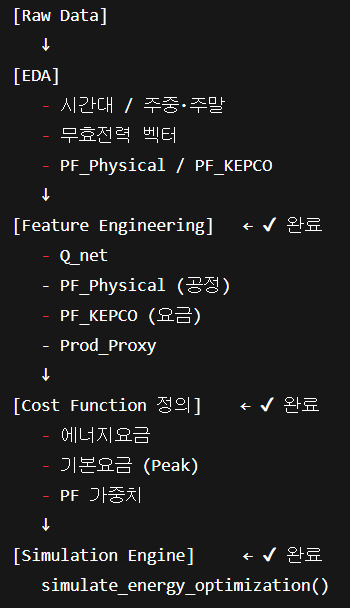

### <b> 

In [ ]:
import optuna
import numpy as np

class ProcessOptimizer:
    def __init__(self, current_monthly_peak, prev_motor_rate, prev_cap_rate, target_prod_rate, config):
        """
        매 15분 최적화 스텝마다 초기화되는 상태 변수들
        """
        self.current_monthly_peak = current_monthly_peak  # 매몰 비용으로 취급할 이번 달 최대 피크
        self.prev_motor_rate = prev_motor_rate            # t-1 시점의 모터 가동률
        self.prev_cap_rate = prev_cap_rate                # t-1 시점의 콘덴서 가동률
        self.target_prod_rate = target_prod_rate          # 이번 15분에 반드시 맞춰야 할 최소 조업 강도 (생산량)
        self.config = config                              # 한전 요금 단가 및 역률 기준 (2026 시나리오 반영 가능)
        
        self.max_delta = 0.1                              # 1번 제약: 15분당 최대 제어 변동폭 (10% 제한)

    def predict_process(self, motor_rate, cap_rate):
        """
        제어 변수(X)를 넣었을 때 사용량과 역률(Y)을 예측하는 ML 모델 (여기서는 더미 로직)
        """
        pred_usage = motor_rate * 500  # 예: 가동률 1.0일 때 500kWh 소비
        pred_pf = 100 - (motor_rate * 20) + (cap_rate * 15) # 부하가 클수록 역률 하락, 콘덴서가 보상
        return pred_usage, min(100.0, pred_pf)

    def objective(self, trial):
        # ----------------------------------------------------------------
        # 1. 제어 변동폭 하드 제약 & 3. 생산량 유지 하드 제약 (Search Space Clipping)
        # ----------------------------------------------------------------
        
        # 모터 가동률 하한선: '이전 상태 - 10%'와 '최소 목표 생산량' 중 더 큰 값
        motor_low = max(self.target_prod_rate, self.prev_motor_rate - self.max_delta)
        # 모터 가동률 상한선: '이전 상태 + 10%' (단, 하한선이 상한선을 역전하는 엣지 케이스 방어)
        motor_high = max(motor_low, min(1.0, self.prev_motor_rate + self.max_delta))
        
        cap_low = max(0.0, self.prev_cap_rate - self.max_delta)
        cap_high = min(1.0, self.prev_cap_rate + self.max_delta)
        
        # Optuna 탐색 범위 자체를 현장의 물리적 한계 내로 종속시킴
        motor_rate = trial.suggest_float("motor_rate", motor_low, motor_high)
        cap_rate = trial.suggest_float("cap_rate", cap_low, cap_high)
        
        # 물리량 예측 (미리 학습된 머신러닝 모델 호출)
        pred_usage, pred_pf = self.predict_process(motor_rate, cap_rate)
        
        # ----------------------------------------------------------------
        # 요금 및 페널티 계산 (보상 함수 Y)
        # ----------------------------------------------------------------
        
        # A. 실시간 변동비 (Marginal Usage Cost)
        usage_cost = pred_usage * self.config['unit_price']
        
        # B. 2번 제약: 매몰 비용을 배제한 동적 피크 페널티 (Dynamic Peak Penalty)
        peak_penalty = 0.0
        if pred_usage > self.current_monthly_peak:
            # 기존 피크를 '초과한 분량'에 대해서만 기본요금 단가(예: 8320원)라는 가혹한 페널티 부여
            peak_penalty = (pred_usage - self.current_monthly_peak) * self.config['base_rate']
            
        # C. 실시간 역률 페널티 (PF Penalty Risk)
        pf_penalty = 0.0
        if pred_pf < self.config['pf_target']:
            pf_gap = self.config['pf_target'] - pred_pf
            # 사용량에 비례하여 역률 페널티 가중치 적용
            pf_penalty = pred_usage * self.config['pf_weight'] * pf_gap
            
        # 최종 목적 함수: 모든 비용의 합을 최소화
        total_marginal_cost = usage_cost + peak_penalty + pf_penalty
        
        return total_marginal_cost

# 실행 예시
# config = {'unit_price': 120, 'base_rate': 8320, 'pf_target': 92.0, 'pf_weight': 100}
# optimizer = ProcessOptimizer(current_monthly_peak=450, prev_motor_rate=0.8, prev_cap_rate=0.5, target_prod_rate=0.75, config=config)
# study = optuna.create_study(direction="minimize")
# study.optimize(optimizer.objective, n_trials=50)

# <b> -- < tCO₂ 계산 로직 (Baseline) > -- 
* 아래 parameter들은 예시 값임 _ API 활용하여 함수 재정의 필요

In [ ]:
import pandas as pd
import numpy as np

# --- [설정값 정의] ---
EMISSION_FACTOR = {2018: 0.000466, 2020: 0.000445, 2022: 0.000430, 2024: 0.000415, 2026: 0.000390}
CARBON_PRICE = {2018: 25000, 2020: 30000, 2022: 35000, 2024: 45000, 2026: 60000}

# --- [비용 계산 함수 정의] ---

def calculate_all_costs(df):
    # 1. 단가 매핑 및 전력량 요금 (Energy_Cost)
    # 이미 get_unit_price 함수가 정의되어 있다고 가정합니다.
    df['unit_price'] = df.apply(get_unit_price, axis=1)
    df['Energy_Cost_KRW'] = df['Usage_kWh'] * df['unit_price']

    # 2. 역률 페널티 (PF_Penalty)
    # 15분 데이터이므로 기본요금을 해당 시간만큼 쪼개서 적용 (비정상 수치 방지)
    def get_fixed_penalty(row):
        pf = row['Power_Factor']
        # 월 기본요금(6160원)을 15분 단위 개수(약 2976개)로 나눔
        basic_rate_per_15min = 6160.0 / (31 * 24 * 4) 
        basic_cost = (row['Usage_kWh'] * 4) * basic_rate_per_15min
        
        diff = pf - 90
        if diff >= 0:
            adj_rate = -min(diff, 25) * 0.002  # 할인
        else:
            adj_rate = min(abs(diff), 100) * 0.002 # 할증
        return basic_cost * adj_rate

    df['PF_Penalty_KRW'] = df.apply(get_fixed_penalty, axis=1)

    # 3. 탄소 비용 (Carbon_Cost)
    df['Emission_Factor'] = df['Year'].map(lambda y: EMISSION_FACTOR.get(y, 0.000390))
    df['Carbon_Price'] = df['Year'].map(lambda y: CARBON_PRICE.get(y, 60000))
    
    df['tCO2'] = df['Usage_kWh'] * df['Emission_Factor']
    df['Carbon_Cost_KRW'] = df['tCO2'] * df['Carbon_Price']

    # 4. 최종 통합 비용
    df['Total_Cost_With_Carbon'] = (
        df['Energy_Cost_KRW'] + 
        df['PF_Penalty_KRW'] + 
        df['Carbon_Cost_KRW']
    )
    
    return df

# 실행
CO2_df = calculate_all_costs(df)
print(CO2_df[['Energy_Cost_KRW', 'PF_Penalty_KRW', 'Carbon_Cost_KRW', 'Total_Cost_With_Carbon']].head())

In [ ]:
import pandas as pd
import requests

# 1. API로부터 데이터를 가져오는 가상의 함수
def get_carbon_data_from_api():
    """
    실제 API 엔드포인트에서 탄소 계수와 가격 정보를 가져옵니다.
    """
    try:
        # 예시 API 주소 (실제 운영되는 API URL로 변경 필요)
        # response = requests.get("https://api.carbon-data.com/v1/factors")
        # data = response.json()
        
        # API 응답 결과가 아래와 같다고 가정합니다.
        api_data = {
            'factors': {2018: 0.000466, 2020: 0.000445, 2022: 0.000430, 2024: 0.000415, 2026: 0.000390},
            'prices': {2018: 25000, 2020: 30000, 2022: 35000, 2024: 45000, 2026: 60000}
        }
        return api_data['factors'], api_data['prices']
    
    except Exception as e:
        print(f"API 호출 오류: {e}")
        # 오류 발생 시 사용할 기본값(Backup) 설정
        return {2026: 0.000390}, {2026: 60000}

# 2. 통합 비용 계산 함수 (API 적용 버전)
def calculate_costs_with_api(df):
    # API 호출 (함수 내부나 외부에서 한 번만 실행)
    api_factors, api_prices = get_carbon_data_from_api()
    
    # [전력 및 페널티 계산 로직은 기존과 동일]
    df['unit_price'] = df.apply(get_unit_price, axis=1)
    df['Energy_Cost_KRW'] = df['Usage_kWh'] * df['unit_price']
    
    # 3. 탄소 데이터 매핑 (API에서 받아온 값 사용)
    # map() 함수를 사용하여 연도별로 API 값을 매칭합니다.
    df['Emission_Factor'] = df['Year'].map(lambda y: api_factors.get(y, 0.000390))
    df['Carbon_Price'] = df['Year'].map(lambda y: api_prices.get(y, 60000))
    
    # 4. 탄소 비용 및 합계 계산
    df['tCO2'] = df['Usage_kWh'] * df['Emission_Factor']
    df['Carbon_Cost_KRW'] = df['tCO2'] * df['Carbon_Price']
    
    df['Total_Cost_With_Carbon'] = (
        df['Energy_Cost_KRW'] + 
        df['PF_Penalty_KRW'] + 
        df['Carbon_Cost_KRW']
    )
    
    return df

# 실행
CO2_df = calculate_costs_with_api(df)
print(CO2_df[['Energy_Cost_KRW', 'PF_Penalty_KRW', 'Carbon_Cost_KRW', 'Total_Cost_With_Carbon']].head())

In [ ]:
df.columns

In [ ]:
import pandas as pd

# 1. 연도별 설정값 정의
EMISSION_FACTOR_BY_YEAR = {2018: 0.000466, 2020: 0.000445, 2022: 0.000430, 2024: 0.000415, 2026: 0.000390}
CARBON_PRICE_BY_YEAR = {2018: 25000, 2020: 30000, 2022: 35000, 2024: 45000, 2026: 60000}

# 2. 전력 요금 및 역률 페널티 계산 (시뮬레이션 코드 로직 기반)
df['Energy_Cost_KRW'] = df['Usage_kWh'] * df['unit_price'] # unit_price가 있다면 사용
df['PF_Penalty_KRW'] = df.apply(calculate_pf_penalty, axis=1)

# 3. 매핑 (Mapping) - lambda보다 훨씬 빠릅니다.
df['Emission_Factor'] = df['Year'].map(lambda y: EMISSION_FACTOR_BY_YEAR.get(y, 0.000390))
df['Carbon_Price'] = df['Year'].map(lambda y: CARBON_PRICE_BY_YEAR.get(y, 60000))

# 4. 탄소 배출량 및 탄소 비용 계산
# tCO2 = 사용량(kWh) * 배출계수(tCO2/kWh)
df['tCO2'] = df['Usage_kWh'] * df['Emission_Factor']

# Carbon_Cost_KRW = 탄소배출량(tCO2) * 탄소가격(원/tCO2)
df['Carbon_Cost_KRW'] = df['tCO2'] * df['Carbon_Price']


# 5. 최종 통합 비용 계산 (전기요금 + 탄소비용)
# 주의: 기존 피처명(Energy_Cost_KRW, PF_Penalty_KRW)이 데이터프레임에 존재해야 합니다.
df['Total_Cost_With_Carbon'] = (
                                    df['Energy_Cost_KRW'] + 
                                    df['PF_Penalty_KRW'] + 
                                    df['Carbon_Cost_KRW']
                                )

print(df[['Usage_kWh', 'tCO2', 'Carbon_Cost_KRW', 'Total_Cost_With_Carbon']].head())

### <b> (1) 연도별 전력 탄소 계수 설계
> 국가 전력 믹스 개선을 반영하여,
kWh당 탄소 배출 계수는 연도에 따라 점진적으로 감소하는 것으로 가정한다.


> 탄소 가격 (KAU) <br>
> 한국 배출권거래제(K-ETS)의 배출권 가격은 한국거래소(KRX)에서 연도별·시기별로 공시

In [ ]:
# 연도별 전력 탄소 배출 계수 (tCO2 / kWh)
EMISSION_FACTOR_BY_YEAR = {
                                2018: 0.000466,
                                2020: 0.000450,
                                2022: 0.000430,
                                2024: 0.000410,
                                2026: 0.000390
                            }

def get_emission_factor(year):
    return EMISSION_FACTOR_BY_YEAR.get(year, 0.000390)

### <b> (2) tCO₂ 계산

In [ ]:
df['Emission_Factor'] = df['Year'].apply(get_emission_factor)
df['tCO2'] = df['Usage_kWh'] * df['Emission_Factor']

### <b> (3) 탄소 비용 함수 (정책 반영 핵심)
> 연도별 탄소 가격 시나리오 <br>
> 탄소 비용은 배출권 거래제의 가격 변동성을 고려 <br>
> -> 연도별 시나리오 파라미터로 정의

In [ ]:
CARBON_PRICE_BY_YEAR = {
                            2018: 25000,
                            2020: 30000,
                            2022: 35000,
                            2024: 45000,
                            2026: 60000
                        }

def get_carbon_price(year):
    return CARBON_PRICE_BY_YEAR.get(year, 60000)

#### <b> (3-1) 연도별 탄소 배출 계수

In [ ]:
def grid_emission_factor(year: int) -> float:
    """
    연도별 전력 탄소 배출 계수 (tCO2 per kWh)
    정책 변화 및 전력 믹스 개선을 반영한 추정 값.
    """
    factor_table = {
        2018: 0.000466,
        2020: 0.000445,
        2022: 0.000430,
        2024: 0.000415,
        2026: 0.000390
    }
    return factor_table.get(year, 0.000390)  # default: 최신 추정치

#### <b> (3-2) 연도별 탄소 가격 함수

In [ ]:
def carbon_price_krw(year: int) -> float:
    """
    연도별 탄소 배출권 가격(KRW / tCO2)
    KAU(KR ETS) 시장 가격 및 정책 예상치를 기반으로 설계.
    """

    price_table = {
        2018: 25000,
        2020: 30000,
        2022: 35000,
        2024: 45000,
        2026: 55000
    }
    return price_table.get(year, 55000)  # default: 정책 강도 높은 시나리오

#### <b> (3-3) 탄소 비용 계산 함수

In [ ]:
def calculate_carbon_cost(df):
    """
    df must include:
        - 'Usage_kWh'
        - 'date' (datetime)
    This function returns:
        - df with 'tCO2', 'Carbon_Cost'
    """

    # 탄소 배출량
    df['tCO2'] = df.apply(
        lambda row: row['Usage_kWh'] * grid_emission_factor(row['Year']),
        axis=1
    )

    # 탄소 비용
    df['Carbon_Cost'] = df.apply(
        lambda row: row['tCO2'] * carbon_price_krw(row['Year']),
        axis=1
    )

    return df

#### <b> (3-4) 최종 비용 함수에 통합

In [ ]:
df.columns

In [ ]:
# 예시: 기존 비용이 df['Total_Cost']로 존재한다면
df = calculate_carbon_cost(df)
df['Total_Cost'] = df['Energy_Cost_KRW'] + df['PF_Penalty_KRW']

# 최종 비용 계산
df['Total_Cost_With_Carbon'] = ( df['Total_Cost'] + df['Carbon_Cost'] )

### <b> (4) 탄소 비용 계산

In [ ]:
df['Carbon_Price'] = df['Year'].apply(get_carbon_price)
df['Carbon_Cost_KRW'] = df['tCO2'] * df['Carbon_Price']

### <b> （5） 총 비용 구조 (보고서에서 제일 중요한 그림)
> 초기 분석에서는 탄소 비용이 전체 비용에서 차지하는 비중이 작아 보일 수 있다. <br>
그러나 동일한 공정 패턴을 2026년 정책 환경에 투영할 경우,<br>
탄소 비용은 PF 페널티와 유사한 수준의 비용 요인으로 성장한다.

In [ ]:
df['Total_Cost_With_Carbon'] = (
                                    df['Energy_Cost_KRW'] +
                                    df['PF_Penalty_KRW'] +
                                    df['Carbon_Cost_KRW']
                                )

In [ ]:
print(df[['Energy_Cost_KRW', 'PF_Penalty_KRW', 'Carbon_Cost_KRW', 'Total_Cost_With_Carbon']].head())

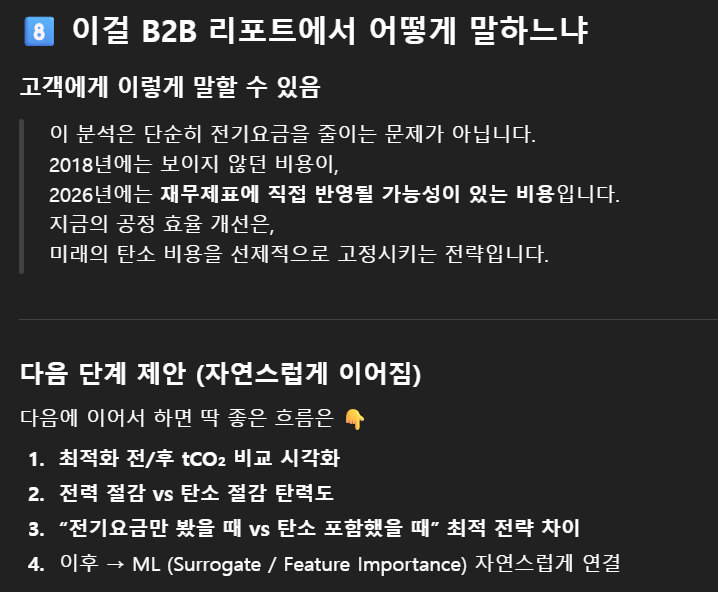

### <b> 